# Show Constant Decoder Memory
Demonstrate that Unlimited-OCR's decoder memory stays constant during generation.

This notebook is the companion to `000-run-unlimited-ocr.py`. It focuses on the
Reference Sliding Window Attention (R-SWA) described in the Unlimited-OCR paper:

    https://github.com/baidu/Unlimited-OCR/blob/main/Unlimited-OCR.pdf

The key claim verified here is that, because every visual token and the prompt
form a fixed reference prefix of length L_m, and because the decoder only keeps
the most recent n output tokens in its KV cache, the total KV cache size is
bounded by L_m + n throughout the whole inference run. Standard full attention
would grow as L_m + T (T = generated length), but R-SWA does not.



In [1]:
import datetime
import gc
import json
import logging
import math
import sys
import tempfile
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Any, Callable, Dict, List, Sequence, Tuple

import fitz
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import torch
from IPython.display import Image as IPImage, Markdown, display
from matplotlib.colors import ListedColormap
from PIL import Image, ImageOps
from torchvision import transforms
from transformers import AutoModel, AutoTokenizer

logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger(__name__)


class Showcase:
    """Save intermediate artifacts, log summaries, and display them inline.

    Parameters
    ----------
    out_dir : Path
        Required. Notebook output directory; artifacts are written to
        ``out_dir / "intermediate"``.
    logger : logging.Logger
        Required. Logger used for artifact summaries.
    """

    def __init__(self, out_dir: Path, logger: logging.Logger):
        """Initialize the showcase helper.

        Parameters
        ----------
        out_dir : Path
            Required. Notebook output directory.
        logger : logging.Logger
            Required. Logger used for artifact summaries.
        """
        self.logger = logger
        self.dir = Path(out_dir) / "intermediate"
        self.dir.mkdir(parents=True, exist_ok=True)

    def _save(self, name: str, writer: Callable[[Path], None]) -> Path:
        """Write an artifact and assert it is non-empty.

        Parameters
        ----------
        name : str
            Required. File name inside the intermediate directory.
        writer : Callable[[Path], None]
            Required. Function that writes the artifact to the given path.

        Returns
        -------
        Path
            Path to the written artifact.
        """
        path = self.dir / name
        writer(path)
        assert path.exists() and path.stat().st_size > 0, f"Empty artifact: {path}"
        self.logger.info("[Showcase] Saved %s (%d bytes)", path, path.stat().st_size)
        return path

    def log_summary(self, name: str, obj: Any) -> None:
        """Log a shape/dtype/length summary for an intermediate object.

        Parameters
        ----------
        name : str
            Required. Human-readable label for the object.
        obj : Any
            Required. Object to summarize.
        """
        if torch.is_tensor(obj):
            self.logger.info(
                "[Showcase] %s: tensor shape=%s dtype=%s",
                name,
                tuple(obj.shape),
                obj.dtype,
            )
        elif isinstance(obj, np.ndarray):
            self.logger.info(
                "[Showcase] %s: ndarray shape=%s dtype=%s",
                name,
                obj.shape,
                obj.dtype,
            )
        elif isinstance(obj, Image.Image):
            self.logger.info(
                "[Showcase] %s: PIL image size=%s mode=%s",
                name,
                obj.size,
                obj.mode,
            )
        elif isinstance(obj, (list, tuple, str)):
            self.logger.info(
                "[Showcase] %s: %s len=%d", name, type(obj).__name__, len(obj)
            )
        else:
            self.logger.info("[Showcase] %s: %s", name, type(obj).__name__)

    def save_image(self, image: Image.Image, name: str, inline: bool = True) -> Path:
        """Save a PIL image, log its size, and display it inline.

        Parameters
        ----------
        image : Image.Image
            Required. Image to save.
        name : str
            Required. Artifact file name.
        inline : bool
            Optional. Whether to display inline. Defaults to True.

        Returns
        -------
        Path
            Path to the saved image.
        """
        self.log_summary(name, image)
        path = self._save(name, lambda p: image.save(p))
        if inline:
            display(IPImage(filename=str(path)))
        return path

    def save_tensor_image(
        self, tensor: torch.Tensor, name: str, inline: bool = True
    ) -> Path:
        """Save a normalized CHW float tensor in [-1, 1] as an image.

        Parameters
        ----------
        tensor : torch.Tensor
            Required. Image tensor of shape [3, H, W] normalized to [-1, 1].
        name : str
            Required. Artifact file name.
        inline : bool
            Optional. Whether to display inline. Defaults to True.

        Returns
        -------
        Path
            Path to the saved image.
        """
        self.log_summary(name, tensor)
        arr = tensor.detach().float().cpu()
        arr = ((arr + 1.0) / 2.0).clamp(0, 1)
        img = Image.fromarray((arr.permute(1, 2, 0).numpy() * 255).astype(np.uint8))
        path = self._save(name, lambda p: img.save(p))
        if inline:
            display(IPImage(filename=str(path)))
        return path

    def save_text(
        self,
        text: str,
        name: str,
        preview_chars: int = 1500,
        inline: bool = True,
    ) -> Path:
        """Save text, log its length, and display a fenced preview.

        Parameters
        ----------
        text : str
            Required. Text to save.
        name : str
            Required. Artifact file name.
        preview_chars : int
            Optional. Number of characters shown inline. Defaults to 1500.
        inline : bool
            Optional. Whether to display inline. Defaults to True.

        Returns
        -------
        Path
            Path to the saved text file.
        """
        self.log_summary(name, text)
        path = self._save(name, lambda p: p.write_text(text, encoding="utf-8"))
        if inline:
            preview = text[:preview_chars]
            if len(text) > preview_chars:
                preview += f"\n... [{len(text) - preview_chars} more chars]"
            display(Markdown(f"```text\n{preview}\n```"))
        return path

    def save_json(
        self, obj: Any, name: str, inline: bool = True, max_lines: int = 40
    ) -> Path:
        """Save an object as JSON and display a pretty preview.

        Parameters
        ----------
        obj : Any
            Required. JSON-serializable object.
        name : str
            Required. Artifact file name.
        inline : bool
            Optional. Whether to display inline. Defaults to True.
        max_lines : int
            Optional. Number of JSON lines shown inline. Defaults to 40.

        Returns
        -------
        Path
            Path to the saved JSON file.
        """
        payload = json.dumps(obj, indent=2, default=str)
        path = self._save(name, lambda p: p.write_text(payload, encoding="utf-8"))
        self.logger.info("[Showcase] %s: %d bytes of JSON", name, len(payload))
        if inline:
            lines = payload.splitlines()
            preview = "\n".join(lines[:max_lines])
            if len(lines) > max_lines:
                preview += f"\n... [{len(lines) - max_lines} more lines]"
            display(Markdown(f"```json\n{preview}\n```"))
        return path

    def save_table(self, df: pd.DataFrame, name: str, inline: bool = True) -> Path:
        """Save a dataframe as CSV, log its shape, and display it inline.

        Parameters
        ----------
        df : pd.DataFrame
            Required. Dataframe to save.
        name : str
            Required. Artifact file name.
        inline : bool
            Optional. Whether to display inline. Defaults to True.

        Returns
        -------
        Path
            Path to the saved CSV file.
        """
        self.logger.info(
            "[Showcase] %s: DataFrame shape=%s columns=%s",
            name,
            df.shape,
            list(df.columns),
        )
        path = self._save(name, lambda p: df.to_csv(p, index=False))
        if inline:
            display(df)
        return path

    def save_figure(
        self, fig: plt.Figure, name: str, dpi: int = 300, inline: bool = True
    ) -> Path:
        """Save a matplotlib figure, display it inline, and close it.

        Parameters
        ----------
        fig : plt.Figure
            Required. Figure to save.
        name : str
            Required. Artifact file name.
        dpi : int
            Optional. Save resolution. Defaults to 300.
        inline : bool
            Optional. Whether to display inline. Defaults to True.

        Returns
        -------
        Path
            Path to the saved figure.
        """
        path = self._save(name, lambda p: fig.savefig(p, dpi=dpi, bbox_inches="tight"))
        if inline:
            display(IPImage(filename=str(path)))
        plt.close(fig)
        return path


@dataclass
class Config:
    """Notebook configuration.

    Parameters
    ----------
    work_dir : Path
        Required. Repository root for resolving relative paths.
    out_dir : Path
        Required. Root directory for all artifacts.
    model_name : str
        Required. Hugging Face model identifier.
    pdf_url : str
        Required. URL to download the Unlimited-OCR paper PDF.
    pdf_cache_path : Path
        Required. Local path to cache the downloaded PDF.
    max_pages : int
        Required. Number of PDF pages to rasterize for the demo.
    sample_dpi : int
        Required. DPI used when rasterizing the PDF.
    image_size : int
        Required. Resolution fed into the multi-page encoder (Base mode).
    patch_size : int
        Required. Vision encoder patch size, used to count visual tokens.
    downsample_ratio : int
        Required. DeepEncoder token compression ratio.
    max_length : int
        Required. Maximum generation length.
    no_repeat_ngram_size : int
        Required. N-gram repetition suppression width.
    dtype : torch.dtype | None
        Optional. Runtime dtype selected after GPU check.
    """

    work_dir: Path
    out_dir: Path
    model_name: str
    pdf_url: str
    pdf_cache_path: Path
    max_pages: int
    sample_dpi: int
    image_size: int
    patch_size: int
    downsample_ratio: int
    max_length: int
    no_repeat_ngram_size: int
    dtype: torch.dtype | None = None

    def replace(self, **kwargs: object) -> "Config":
        """Return a new Config with the given fields replaced."""
        return replace(self, **kwargs)


CONFIG = Config(
    work_dir=Path.cwd(),
    out_dir=Path(
        f"outputs/{datetime.datetime.now().strftime('%Y-%m-%d')}/000-unlimited-ocr-demo/002-attentionconstant"
    ),
    model_name="baidu/Unlimited-OCR",
    pdf_url="https://github.com/baidu/Unlimited-OCR/raw/main/Unlimited-OCR.pdf",
    pdf_cache_path=Path("inputs/Unlimited-OCR.pdf"),
    max_pages=2,
    sample_dpi=300,
    image_size=1024,
    patch_size=16,
    downsample_ratio=4,
    max_length=2048,
    no_repeat_ngram_size=5,
)
CONFIG.out_dir.mkdir(parents=True, exist_ok=True)
_file_handler = logging.FileHandler(CONFIG.out_dir / "run.log", mode="w")
_file_handler.setFormatter(logging.Formatter("%(message)s"))
logging.getLogger().addHandler(_file_handler)
showcase = Showcase(CONFIG.out_dir, logger)
logger.info(
    "Config: out_dir=%s pdf_url=%s max_pages=%s",
    CONFIG.out_dir,
    CONFIG.pdf_url,
    CONFIG.max_pages,
)




Config: out_dir=outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant pdf_url=https://github.com/baidu/Unlimited-OCR/raw/main/Unlimited-OCR.pdf max_pages=2


## Check Environment
Verify CUDA availability and choose bfloat16 when the GPU supports it.




In [2]:
class EnvironmentChecker:
    """Select the best inference dtype for the available GPU.

    Parameters
    ----------
    config : Config
        Required. Global configuration.
    """

    def __init__(self, config: Config):
        """Initialize with global config.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        """
        self.config = config

    def check(self) -> torch.dtype:
        """Return bfloat16 if supported, otherwise float16.

        Returns
        -------
        torch.dtype
            Selected dtype.
        """
        assert torch.cuda.is_available(), "CUDA unavailable"
        gpu_name = torch.cuda.get_device_name(0)
        dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
        logger.info("[EnvironmentChecker] GPU: %s", gpu_name)
        logger.info("[EnvironmentChecker] dtype: %s", dtype)
        return dtype


env_checker = EnvironmentChecker(CONFIG)
CONFIG = CONFIG.replace(dtype=env_checker.check())
logger.info("Outputs: CONFIG.dtype=%s", CONFIG.dtype)




[EnvironmentChecker] GPU: NVIDIA GeForce RTX 3090
[EnvironmentChecker] dtype: torch.bfloat16
Outputs: CONFIG.dtype=torch.bfloat16


## Load Model
Load the Unlimited-OCR tokenizer and model.  The decoder uses R-SWA when
`config.use_mla=False` and `config.sliding_window` is set.




In [3]:
class ModelLoader:
    """Load the Unlimited-OCR tokenizer and model.

    Parameters
    ----------
    config : Config
        Required. Global configuration with model_name and dtype.
    """

    def __init__(self, config: Config):
        """Initialize with global config.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        """
        self.config = config

    def load(self) -> Tuple[AutoTokenizer, AutoModel]:
        """Download and load the model onto the GPU.

        Returns
        -------
        Tuple[AutoTokenizer, AutoModel]
            Tokenizer and model ready for inference.
        """
        logger.info("[ModelLoader] Loading %s ...", self.config.model_name)
        tokenizer = AutoTokenizer.from_pretrained(
            self.config.model_name, trust_remote_code=True
        )
        model = AutoModel.from_pretrained(
            self.config.model_name,
            trust_remote_code=True,
            use_safetensors=True,
            torch_dtype=self.config.dtype,
        )
        model = model.eval().cuda()
        logger.info("[ModelLoader] Model loaded")
        return tokenizer, model


model_loader = ModelLoader(CONFIG)
tokenizer, model = model_loader.load()
logger.info(
    "Outputs: tokenizer=%s model=%s",
    type(tokenizer).__name__,
    type(model).__name__,
)




[ModelLoader] Loading baidu/Unlimited-OCR ...
`torch_dtype` is deprecated! Use `dtype` instead!
Some weights of UnlimitedOCRForCausalLM were not initialized from the model checkpoint at baidu/Unlimited-OCR and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[ModelLoader] Model loaded
Outputs: tokenizer=LlamaTokenizerFast model=UnlimitedOCRForCausalLM


## Inspect R-SWA Configuration
Print the attention class and the sliding-window size.  In the paper these are
the reference (visual+prompt) tokens of length L_m and the recent output window
of width n (default 128).




In [4]:
class AttentionConfigInspector:
    """Read and log the decoder's sliding-window / R-SWA settings.

    Parameters
    ----------
    model : AutoModel
        Required. Loaded Unlimited-OCR model.
    """

    def __init__(self, model: AutoModel):
        """Initialize with the loaded model.

        Parameters
        ----------
        model : AutoModel
            Required. Loaded model.
        """
        self.model = model

    def inspect(self) -> Dict[str, object]:
        """Return a dictionary of relevant attention settings.

        Returns
        -------
        Dict[str, object]
            Settings read from the model config and first decoder layer.
        """
        cfg = self.model.config
        first_layer = self.model.model.layers[0]
        recent_window = getattr(cfg, "sliding_window", None) or getattr(
            cfg, "sliding_window_size", None
        )
        info = {
            "use_mla": getattr(cfg, "use_mla", None),
            "attn_implementation": getattr(cfg, "_attn_implementation", None),
            "sliding_window": recent_window,
            "num_hidden_layers": cfg.num_hidden_layers,
            "num_attention_heads": cfg.num_attention_heads,
            "num_key_value_heads": getattr(cfg, "num_key_value_heads", None),
            "hidden_size": cfg.hidden_size,
            "attention_class": type(first_layer.self_attn).__name__,
        }
        logger.info("[AttentionConfigInspector] R-SWA settings:")
        for key, value in info.items():
            logger.info("  %s = %s", key, value)
        return info


attn_inspector = AttentionConfigInspector(model)
ATTN_INFO = attn_inspector.inspect()
logger.info("Outputs: ATTN_INFO=%s", ATTN_INFO)
assert (
    ATTN_INFO["attention_class"].lower().startswith("sliding")
), "Expected SlidingWindowLlamaAttention for the R-SWA demo"




[AttentionConfigInspector] R-SWA settings:
  use_mla = False
  attn_implementation = eager
  sliding_window = 128
  num_hidden_layers = 12
  num_attention_heads = 10
  num_key_value_heads = 10
  hidden_size = 1280
  attention_class = SlidingWindowLlamaAttention
Outputs: ATTN_INFO={'use_mla': False, 'attn_implementation': 'eager', 'sliding_window': 128, 'num_hidden_layers': 12, 'num_attention_heads': 10, 'num_key_value_heads': 10, 'hidden_size': 1280, 'attention_class': 'SlidingWindowLlamaAttention'}


## Load the Unlimited-OCR Paper Pages
Download the paper PDF and rasterize the first `max_pages` pages.  These pages
become the visual reference tokens that the decoder can attend to throughout
generation.




In [5]:
class DocumentLoader:
    """Download the Unlimited-OCR PDF and rasterize the first pages.

    Parameters
    ----------
    config : Config
        Required. Global configuration.
    """

    def __init__(self, config: Config):
        """Initialize with global config.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        """
        self.config = config

    def load(self) -> List[Path]:
        """Download and rasterize pages, returning PNG paths in order.

        Returns
        -------
        List[Path]
            Paths to rasterized page images.
        """
        cache_path = self.config.pdf_cache_path
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        if not cache_path.exists():
            logger.info("[DocumentLoader] Downloading %s", self.config.pdf_url)
            response = requests.get(self.config.pdf_url, timeout=120)
            response.raise_for_status()
            cache_path.write_bytes(response.content)
            logger.info(
                "[DocumentLoader] Saved PDF to %s (%s bytes)",
                cache_path,
                len(response.content),
            )

        pages_dir = self.config.out_dir / "inputs" / "pages"
        pages_dir.mkdir(parents=True, exist_ok=True)

        doc = fitz.open(cache_path)
        mat = fitz.Matrix(self.config.sample_dpi / 72, self.config.sample_dpi / 72)
        paths: List[Path] = []
        for i in range(min(self.config.max_pages, len(doc))):
            out_path = pages_dir / f"page_{i + 1:04d}.png"
            doc[i].get_pixmap(matrix=mat).save(str(out_path))
            paths.append(out_path)
        doc.close()

        logger.info(
            "[DocumentLoader] Rasterized %s pages to %s",
            len(paths),
            pages_dir,
        )
        return paths


document_loader = DocumentLoader(CONFIG)
page_paths = document_loader.load()
logger.info(
    "Outputs: loaded %s pages, first=%s",
    len(page_paths),
    page_paths[0],
)
for p in page_paths:
    assert p.exists(), f"Missing page: {p}"




[DocumentLoader] Downloading https://github.com/baidu/Unlimited-OCR/raw/main/Unlimited-OCR.pdf
[DocumentLoader] Saved PDF to inputs/Unlimited-OCR.pdf (460324 bytes)
[DocumentLoader] Rasterized 2 pages to outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/inputs/pages
Outputs: loaded 2 pages, first=outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/inputs/pages/page_0001.png


## Showcase: Input Page Image
Save the first rasterized page to `intermediate/`, log its shape, and display it.




[Showcase] 00_input_page.png: PIL image size=(2481, 3508) mode=RGB
[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/00_input_page.png (658777 bytes)


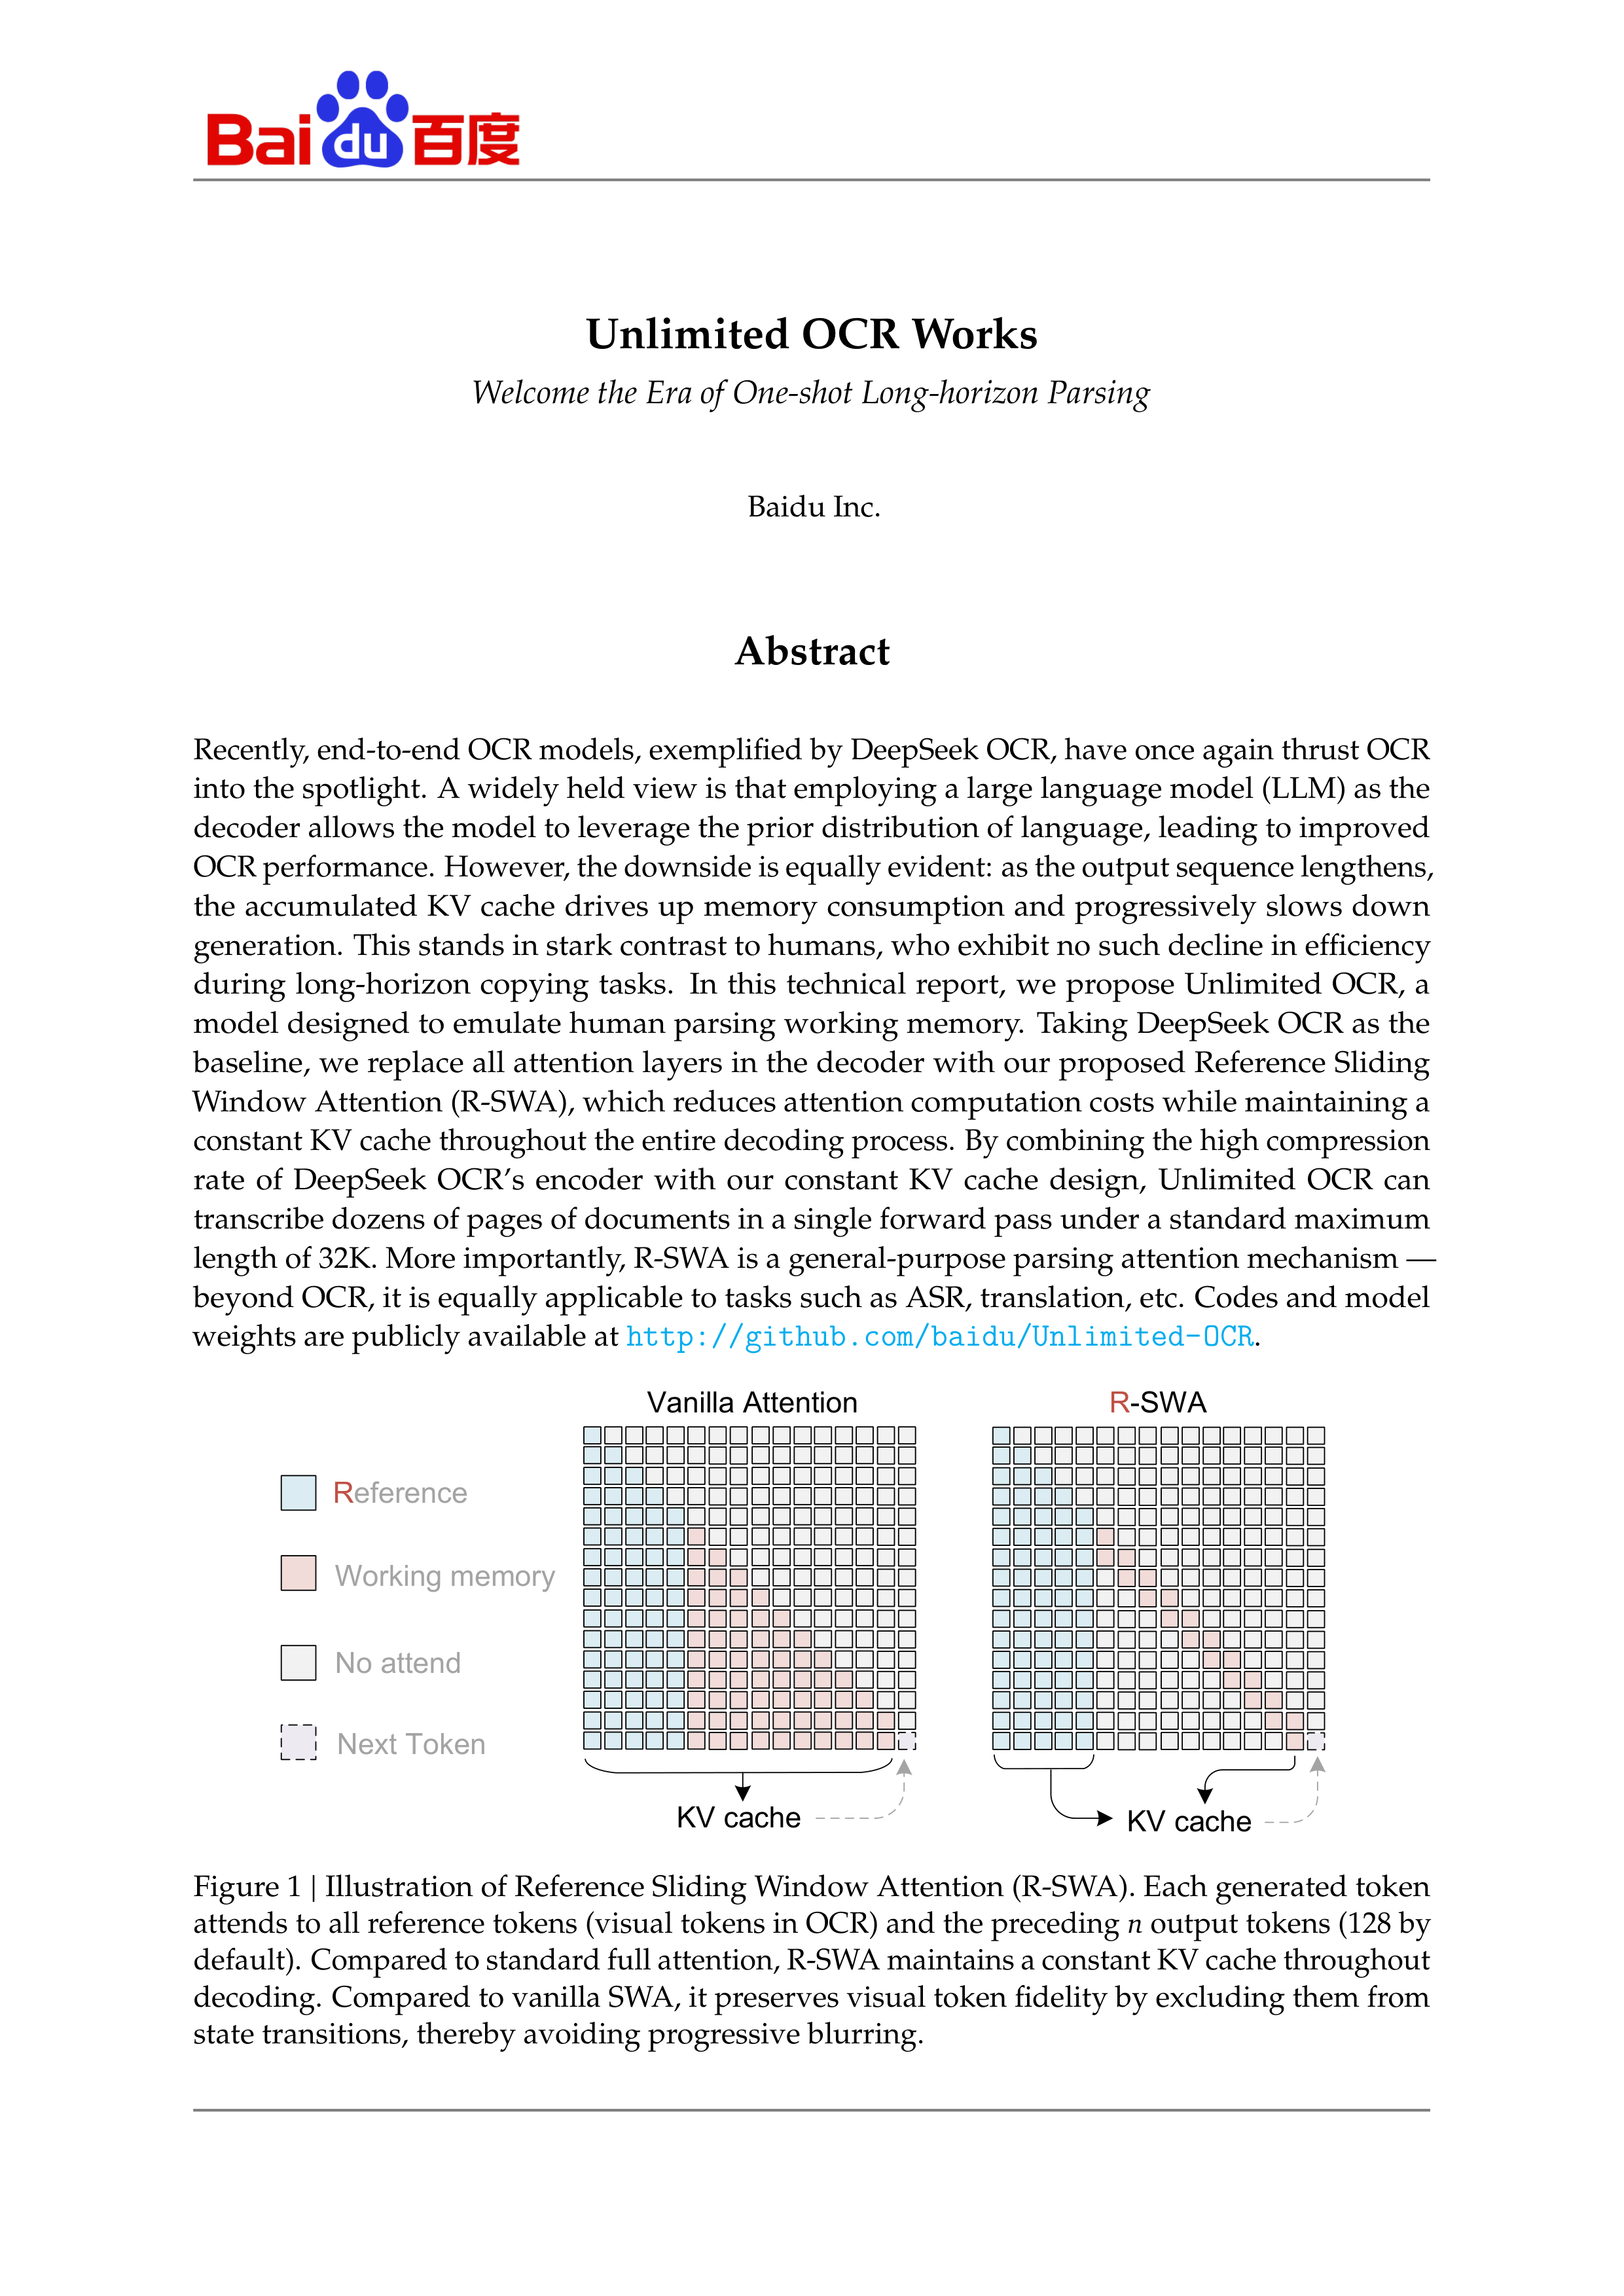

[InputPageShowcase] input size (W, H)=(2481, 3508)
Outputs: input_page_image.size=(2481, 3508)


In [6]:
class InputPageShowcase:
    """Save and display the first input page image.

    Parameters
    ----------
    showcase : Showcase
        Required. Shared save/log/display helper.
    """

    def __init__(self, showcase: Showcase):
        """Initialize with the showcase helper.

        Parameters
        ----------
        showcase : Showcase
            Required. Shared save/log/display helper.
        """
        self.showcase = showcase

    def run(self, image_path: Path) -> Image.Image:
        """Save and display the input page.

        Parameters
        ----------
        image_path : Path
            Required. Path to the rasterized page.

        Returns
        -------
        Image.Image
            Loaded RGB image.
        """
        image = Image.open(image_path).convert("RGB")
        self.showcase.save_image(image, "00_input_page.png")
        logger.info("[InputPageShowcase] input size (W, H)=%s", image.size)
        return image


input_page_showcase = InputPageShowcase(showcase)
input_page_image = input_page_showcase.run(page_paths[0])
logger.info("Outputs: input_page_image.size=%s", input_page_image.size)
assert input_page_image.size[0] > 0




## Build Multi-page Model Inputs
Replicate the non-crop multi-page preprocessing used by `model.infer_multi`.
The prompt contains a single `<image>` token; all pages' visual tokens are
inserted at that position, separated by a single image-token separator.




In [7]:
class MultiPageInputBuilder:
    """Build tokenized inputs and image tensors for multi-page generation.

    Parameters
    ----------
    config : Config
        Required. Global configuration.
    tokenizer : AutoTokenizer
        Required. Loaded tokenizer.
    """

    IMAGE_TOKEN = "<image>"
    BOS_ID = 0

    def __init__(self, config: Config, tokenizer: AutoTokenizer):
        """Initialize with config and tokenizer.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        tokenizer : AutoTokenizer
            Required. Loaded tokenizer.
        """
        self.config = config
        self.tokenizer = tokenizer
        self.image_token_id = tokenizer.convert_tokens_to_ids(self.IMAGE_TOKEN)
        if isinstance(self.image_token_id, int) and self.image_token_id < 0:
            self.image_token_id = 128815  # fallback used by the reference model
        self.transform = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            ]
        )

    def _pad_image(self, image: Image.Image, size: int) -> Image.Image:
        """Pad an image to a square canvas of the given size.

        Parameters
        ----------
        image : Image.Image
            Required. Source image.
        size : int
            Required. Target side length.

        Returns
        -------
        Image.Image
            Square padded RGB image.
        """
        return ImageOps.pad(image.convert("RGB"), (size, size), color=(255, 255, 255))

    def build(
        self, image_paths: Sequence[Path], prompt: str
    ) -> Dict[str, torch.Tensor]:
        """Create generation inputs for the model.

        Parameters
        ----------
        image_paths : Sequence[Path]
            Required. Page images in order.
        prompt : str
            Required. Prompt containing a single `<image>` token.

        Returns
        -------
        Dict[str, torch.Tensor]
            Dictionary with input_ids, attention_mask, images_seq_mask,
            images_ori, images_crop, and images_spatial_crop.
        """
        size = self.config.image_size
        patch = self.config.patch_size
        ratio = self.config.downsample_ratio
        num_queries = math.ceil((size // patch) / ratio)

        text_splits = prompt.split(self.IMAGE_TOKEN)
        assert len(text_splits) == 2, "Prompt must contain exactly one <image> token"

        input_ids: List[int] = []
        images_seq_mask: List[bool] = []
        images_list: List[torch.Tensor] = []
        spatial_crop: List[List[int]] = []

        # text before <image>
        before_ids = self.tokenizer.encode(text_splits[0], add_special_tokens=False)
        input_ids.extend(before_ids)
        images_seq_mask.extend([False] * len(before_ids))

        # each page contributes the same visual token pattern
        for path in image_paths:
            pil_img = Image.open(path).convert("RGB")
            padded = self._pad_image(pil_img, size)
            images_list.append(self.transform(padded).to(self.config.dtype))
            spatial_crop.append([1, 1])

            tokenized_image = (
                [self.image_token_id] * num_queries + [self.image_token_id]
            ) * num_queries + [self.image_token_id]
            input_ids.extend(tokenized_image)
            images_seq_mask.extend([True] * len(tokenized_image))

        # text after <image>
        after_ids = self.tokenizer.encode(text_splits[1], add_special_tokens=False)
        input_ids.extend(after_ids)
        images_seq_mask.extend([False] * len(after_ids))

        # add bos
        input_ids = [self.BOS_ID] + input_ids
        images_seq_mask = [False] + images_seq_mask

        images_ori = torch.stack(images_list, dim=0)
        inputs = {
            "input_ids": torch.LongTensor(input_ids).unsqueeze(0),
            "attention_mask": torch.ones((1, len(input_ids)), dtype=torch.long),
            "images_seq_mask": torch.tensor(
                images_seq_mask, dtype=torch.bool
            ).unsqueeze(0),
            "images_ori": images_ori,
            "images_crop": torch.zeros((1, 3, size, size), dtype=self.config.dtype),
            "images_spatial_crop": torch.tensor(spatial_crop, dtype=torch.long),
        }
        logger.info(
            "[MultiPageInputBuilder] input_ids=%s visual_tokens=%d",
            inputs["input_ids"].shape,
            sum(images_seq_mask),
        )
        return inputs


input_builder = MultiPageInputBuilder(CONFIG, tokenizer)
PROMPT = "<image>Multi page parsing."
inputs = input_builder.build(page_paths, PROMPT)
logger.info("Outputs: inputs keys=%s", list(inputs.keys()))




[MultiPageInputBuilder] input_ids=torch.Size([1, 551]) visual_tokens=546
Outputs: inputs keys=['input_ids', 'attention_mask', 'images_seq_mask', 'images_ori', 'images_crop', 'images_spatial_crop']


## Compute the Token Budget
Show the reference token count (visual + prompt) and the recent-token window.
The R-SWA cache is bounded by `L_m + n`, where `n = config.sliding_window`.
This matches Eq. (6) in the paper.




In [8]:
class TokenBudgetInspector:
    """Compute and log the R-SWA token budget and theoretical KV-cache size.

    Parameters
    ----------
    config : Config
        Required. Global configuration.
    model : AutoModel
        Required. Loaded model.
    inputs : Dict[str, torch.Tensor]
        Required. Tokenized inputs produced by MultiPageInputBuilder.
    """

    def __init__(
        self, config: Config, model: AutoModel, inputs: Dict[str, torch.Tensor]
    ):
        """Initialize with config, model, and inputs.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        model : AutoModel
            Required. Loaded model.
        inputs : Dict[str, torch.Tensor]
            Required. Tokenized inputs.
        """
        self.config = config
        self.model = model
        self.inputs = inputs

    def inspect(self) -> Dict[str, float]:
        """Return reference length, recent window, and upper-bound cache length.

        Returns
        -------
        Dict[str, float]
            Token-budget numbers.
        """
        cfg = self.model.config
        recent_window = getattr(cfg, "sliding_window", None) or getattr(
            cfg, "sliding_window_size", None
        )
        if recent_window is None:
            recent_window = 0

        seq_mask = self.inputs["images_seq_mask"][0]
        visual_tokens = int(seq_mask.sum().item())
        prompt_tokens = int((~seq_mask).sum().item())
        reference_tokens = visual_tokens + prompt_tokens

        # upper-bound cache tokens after the ring buffer is warm
        upper_bound_tokens = reference_tokens + recent_window

        # bytes per KV cache token for the decoder
        dtype_bytes = 2 if self.config.dtype == torch.bfloat16 else 4
        bytes_per_token = (
            2
            * cfg.num_hidden_layers
            * cfg.num_attention_heads
            * (cfg.hidden_size // cfg.num_attention_heads)
            * dtype_bytes
        )

        budget = {
            "visual_tokens": visual_tokens,
            "prompt_tokens": prompt_tokens,
            "reference_tokens": reference_tokens,
            "recent_window": recent_window,
            "upper_bound_cache_tokens": upper_bound_tokens,
            "upper_bound_cache_mb": (upper_bound_tokens * bytes_per_token) / (1024**2),
        }
        logger.info("[TokenBudgetInspector] Token budget:")
        for key, value in budget.items():
            logger.info("  %s = %s", key, value)
        return budget


budget_inspector = TokenBudgetInspector(CONFIG, model, inputs)
TOKEN_BUDGET = budget_inspector.inspect()
logger.info("Outputs: TOKEN_BUDGET=%s", TOKEN_BUDGET)
assert TOKEN_BUDGET["recent_window"] > 0, "sliding_window must be positive for R-SWA"

# Showcase: save the token budget as JSON and display it.
showcase.save_json(TOKEN_BUDGET, "01_token_budget.json")




[TokenBudgetInspector] Token budget:
  visual_tokens = 546
  prompt_tokens = 5
  reference_tokens = 551
  recent_window = 128
  upper_bound_cache_tokens = 679
  upper_bound_cache_mb = 39.78515625
Outputs: TOKEN_BUDGET={'visual_tokens': 546, 'prompt_tokens': 5, 'reference_tokens': 551, 'recent_window': 128, 'upper_bound_cache_tokens': 679, 'upper_bound_cache_mb': 39.78515625}
[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/01_token_budget.json (173 bytes)
[Showcase] 01_token_budget.json: 173 bytes of JSON


```json
{
  "visual_tokens": 546,
  "prompt_tokens": 5,
  "reference_tokens": 551,
  "recent_window": 128,
  "upper_bound_cache_tokens": 679,
  "upper_bound_cache_mb": 39.78515625
}
```

PosixPath('outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/01_token_budget.json')

## Visualize the R-SWA Receptive Field
Draw the attention mask that R-SWA uses.  Every query (row) can attend to every
reference token (green prefix) and only to the latest n generated tokens (blue
diagonal).  Older generated tokens are soft-forgotten (white).  This is exactly
Figure 2 of the paper.




In [9]:
class AttentionReceptiveFieldPlotter:
    """Draw a clean R-SWA attention-mask matrix."""

    def __init__(self, config: Config):
        """Initialize with global config.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        """
        self.config = config

    def plot(
        self,
        reference_tokens: int,
        recent_window: int,
        generated_tokens: int,
    ) -> Path:
        """Save an R-SWA attention-mask diagram.

        Parameters
        ----------
        reference_tokens : int
            Required. Number of visual + prompt tokens (L_m).
        recent_window : int
            Required. Recent-output window width (n).
        generated_tokens : int
            Required. Number of generated tokens (T) to visualize.

        Returns
        -------
        Path
            Path to the saved PNG.
        """
        out_path = self.config.out_dir / "plots" / "attention_receptive_field.png"
        out_path.parent.mkdir(parents=True, exist_ok=True)

        # Use a clipped window so the figure stays readable.
        ref_display = min(reference_tokens, 100)
        gen_display = min(generated_tokens, 300)
        total_display = ref_display + gen_display

        # 0 = soft-forgotten / future (light gray)
        # 1 = reference tokens (always visible)
        # 2 = recent generated tokens (sliding window)
        mask = np.zeros((gen_display, total_display), dtype=np.uint8)

        # all queries see the whole reference prefix
        mask[:, :ref_display] = 1

        # each query t sees only the latest n generated tokens before it
        for t in range(gen_display):
            start_gen = max(0, t - recent_window + 1)
            end_gen = t + 1  # causal: current token is included
            col_start = ref_display + start_gen
            col_end = ref_display + end_gen
            mask[t, col_start:col_end] = 2

        # stash the mask for the showcase cell
        self.last_mask = mask

        # custom colors: light gray, green, blue
        cmap = ListedColormap(["#e8e8e8", "#2ecc71", "#3498db"])

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.imshow(
            mask,
            cmap=cmap,
            aspect="auto",
            interpolation="nearest",
            origin="upper",
            extent=[0, total_display, gen_display, 0],
        )

        # vertical separator between reference and decode regions
        ax.axvline(x=ref_display, color="black", lw=1.5)

        ax.set_xlabel("Key position (token index)")
        ax.set_ylabel("Decode query step (token index)")
        fig.suptitle(
            "R-SWA attention receptive field: reference tokens always visible, "
            f"only the latest {recent_window} output tokens visible per query",
            y=1.02,
        )

        # legend patches
        ref_patch = mpatches.Patch(
            facecolor="#2ecc71", label=f"Reference tokens (L_m = {reference_tokens})"
        )
        recent_patch = mpatches.Patch(
            facecolor="#3498db", label=f"Recent {recent_window} output tokens"
        )
        forget_patch = mpatches.Patch(
            facecolor="#e8e8e8",
            edgecolor="gray",
            label="Soft-forgotten output tokens",
        )
        ax.legend(
            handles=[ref_patch, recent_patch, forget_patch],
            loc="lower right",
            framealpha=0.95,
        )

        plt.tight_layout()
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.close(fig)
        logger.info("[AttentionReceptiveFieldPlotter] Saved %s", out_path)
        return out_path


field_plotter = AttentionReceptiveFieldPlotter(CONFIG)
receptive_field_path = field_plotter.plot(
    reference_tokens=TOKEN_BUDGET["reference_tokens"],
    recent_window=TOKEN_BUDGET["recent_window"],
    generated_tokens=CONFIG.max_length,
)
logger.info("Outputs: receptive_field_path=%s", receptive_field_path)
assert receptive_field_path.exists()




[AttentionReceptiveFieldPlotter] Saved outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/plots/attention_receptive_field.png
Outputs: receptive_field_path=outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/plots/attention_receptive_field.png


## Showcase: Receptive-Field Mask
Save the raw R-SWA attention mask (`.npy`), log its shape, and render a
Seaborn heatmap of it at 300 DPI.




[Showcase] receptive_field_mask: ndarray shape=(300, 400) dtype=uint8
[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/02_receptive_field_mask.npy
[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/02_receptive_field_mask_heatmap.png (183045 bytes)


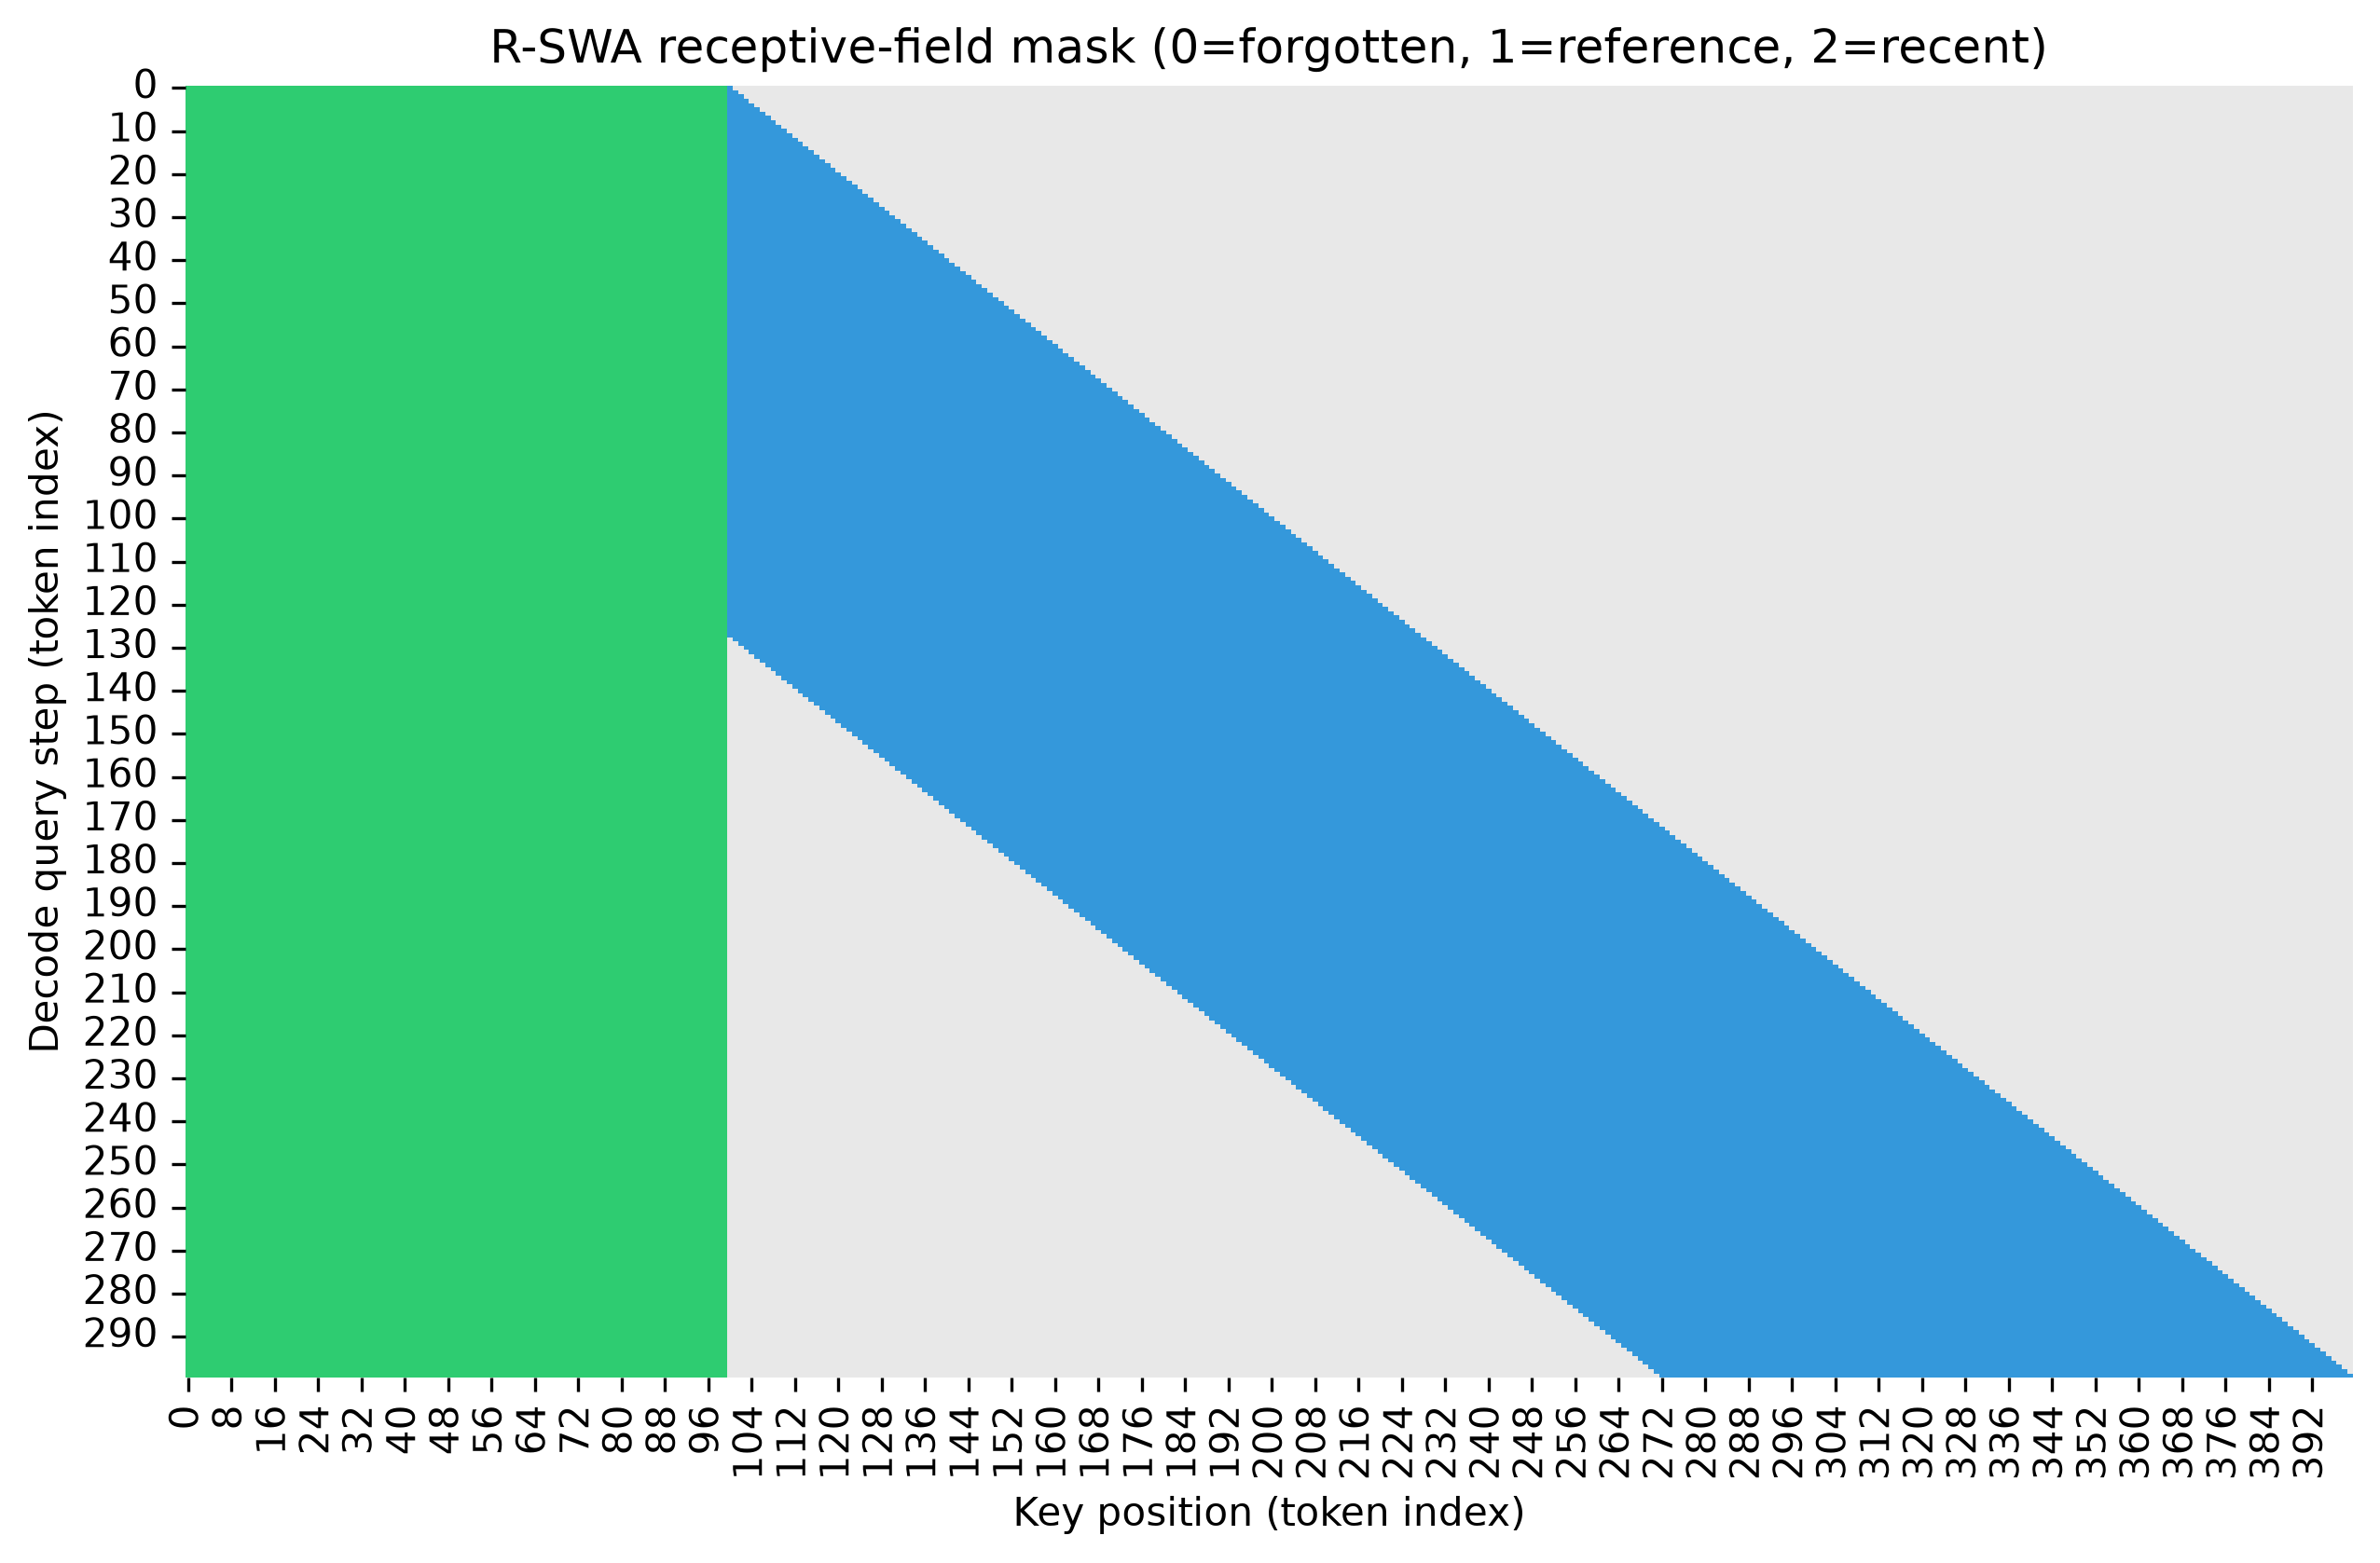

Outputs: rf_heatmap_path=outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/02_receptive_field_mask_heatmap.png


In [10]:
class ReceptiveFieldShowcase:
    """Save and display the raw R-SWA receptive-field mask.

    Parameters
    ----------
    showcase : Showcase
        Required. Shared save/log/display helper.
    """

    def __init__(self, showcase: Showcase):
        """Initialize with the showcase helper.

        Parameters
        ----------
        showcase : Showcase
            Required. Shared save/log/display helper.
        """
        self.showcase = showcase

    def run(self, mask: np.ndarray) -> Path:
        """Save the mask array and a Seaborn heatmap of it.

        Parameters
        ----------
        mask : np.ndarray
            Required. Mask with 0=forgotten, 1=reference, 2=recent.

        Returns
        -------
        Path
            Path to the saved heatmap.
        """
        self.showcase.log_summary("receptive_field_mask", mask)
        npy_path = self.showcase.dir / "02_receptive_field_mask.npy"
        np.save(npy_path, mask)
        assert npy_path.exists() and npy_path.stat().st_size > 0
        logger.info("[Showcase] Saved %s", npy_path)

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.heatmap(
            mask,
            cmap=sns.color_palette(["#e8e8e8", "#2ecc71", "#3498db"]),
            cbar=False,
            ax=ax,
        )
        ax.set_xlabel("Key position (token index)")
        ax.set_ylabel("Decode query step (token index)")
        ax.set_title("R-SWA receptive-field mask (0=forgotten, 1=reference, 2=recent)")
        return self.showcase.save_figure(fig, "02_receptive_field_mask_heatmap.png")


receptive_field_showcase = ReceptiveFieldShowcase(showcase)
rf_heatmap_path = receptive_field_showcase.run(field_plotter.last_mask)
logger.info("Outputs: rf_heatmap_path=%s", rf_heatmap_path)
assert rf_heatmap_path.exists()




## Profile Memory During Generation
Attach a forward hook to record GPU allocated and peak allocated memory after
every decoder forward call. Step 0 is the prefill pass; subsequent steps are
autoregressive decode steps. With R-SWA the KV cache is bounded, so allocated
memory should stop growing once the ring buffer is full, and the peak since
reset should therefore plateau too.




In [11]:
class GenerationMemoryProfiler:
    """Run generation while recording per-step GPU memory.

    Parameters
    ----------
    config : Config
        Required. Global configuration.
    model : AutoModel
        Required. Loaded model.
    tokenizer : AutoTokenizer
        Required. Loaded tokenizer.
    inputs : Dict[str, torch.Tensor]
        Required. Tokenized inputs.
    """

    def __init__(
        self,
        config: Config,
        model: AutoModel,
        tokenizer: AutoTokenizer,
        inputs: Dict[str, torch.Tensor],
    ):
        """Initialize profiler.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        model : AutoModel
            Required. Loaded model.
        tokenizer : AutoTokenizer
            Required. Loaded tokenizer.
        inputs : Dict[str, torch.Tensor]
            Required. Tokenized inputs.
        """
        self.config = config
        self.model = model
        self.tokenizer = tokenizer
        self.inputs = inputs
        self.trace: List[Dict[str, float]] = []
        self.output_ids: torch.Tensor | None = None
        self._step = 0

    def _make_hook(self):
        """Return a forward hook that logs allocated and peak memory after every decoder call."""

        def hook(module, inp, out):
            seq_len = out[0].shape[1]
            self.trace.append(
                {
                    "step": self._step,
                    "seq_len": seq_len,
                    "allocated_mb": torch.cuda.memory_allocated() / (1024**2),
                    "peak_mb": torch.cuda.max_memory_allocated() / (1024**2),
                }
            )
            self._step += 1

        return hook

    def run(self) -> Tuple[List[Dict[str, float]], torch.Tensor]:
        """Run generation and return the memory trace plus generated ids.

        Returns
        -------
        Tuple[List[Dict[str, float]], torch.Tensor]
            Memory trace and output token ids.
        """
        # move inputs to GPU
        gen_inputs = {
            "input_ids": self.inputs["input_ids"].cuda(),
            "attention_mask": self.inputs["attention_mask"].cuda(),
            "images": [
                (self.inputs["images_crop"].cuda(), self.inputs["images_ori"].cuda())
            ],
            "images_seq_mask": self.inputs["images_seq_mask"].cuda(),
            "images_spatial_crop": self.inputs["images_spatial_crop"],
        }

        hook_handle = self.model.model.register_forward_hook(self._make_hook())
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()
        gc.collect()
        self._baseline_mb = torch.cuda.memory_allocated() / (1024**2)

        try:
            with torch.autocast("cuda", dtype=self.config.dtype), torch.no_grad():
                self.output_ids = self.model.generate(
                    **gen_inputs,
                    eos_token_id=self.tokenizer.eos_token_id,
                    pad_token_id=self.tokenizer.eos_token_id,
                    max_length=self.config.max_length,
                    no_repeat_ngram_size=self.config.no_repeat_ngram_size,
                    use_cache=True,
                )
        finally:
            hook_handle.remove()

        generated = int(self.output_ids.shape[1] - gen_inputs["input_ids"].shape[1])
        logger.info(
            "[GenerationMemoryProfiler] recorded %s forward steps, generated %s tokens",
            len(self.trace),
            generated,
        )
        return self.trace, self.output_ids


profiler = GenerationMemoryProfiler(CONFIG, model, tokenizer, inputs)
MEMORY_TRACE, OUTPUT_IDS = profiler.run()
generated_count = int(OUTPUT_IDS.shape[1] - inputs["input_ids"].shape[1])
logger.info("Outputs: generated_count=%d", generated_count)
assert (
    generated_count > TOKEN_BUDGET["recent_window"]
), "Need more generated tokens than the recent window to observe the plateau"




[GenerationMemoryProfiler] recorded 1497 forward steps, generated 1497 tokens
Outputs: generated_count=1497


## Showcase: Memory Trace
Log the trace array shape and save a sample (first/last steps) plus a 300-DPI
Seaborn line plot of allocated memory per forward step.




[Showcase] allocated_mb: ndarray shape=(1497,) dtype=float64
[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/03_memory_trace_sample.json (857 bytes)
[Showcase] 03_memory_trace_sample.json: 857 bytes of JSON


```json
{
  "num_steps": 1497,
  "allocated_mb_shape": [
    1497
  ],
  "first_steps": [
    {
      "step": 0,
      "seq_len": 551,
      "allocated_mb": 6517.47509765625,
      "peak_mb": 6933.67919921875
    },
    {
      "step": 1,
      "seq_len": 1,
      "allocated_mb": 6492.33935546875,
      "peak_mb": 6933.67919921875
    },
    {
      "step": 2,
      "seq_len": 1,
      "allocated_mb": 6492.33935546875,
      "peak_mb": 6933.67919921875
    }
  ],
  "last_steps": [
    {
      "step": 1494,
      "seq_len": 1,
      "allocated_mb": 6492.373046875,
      "peak_mb": 6933.67919921875
    },
    {
      "step": 1495,
      "seq_len": 1,
      "allocated_mb": 6492.373046875,
      "peak_mb": 6933.67919921875
    },
    {
      "step": 1496,
... [6 more lines]
```

[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/03_memory_trace_seaborn.png (94415 bytes)


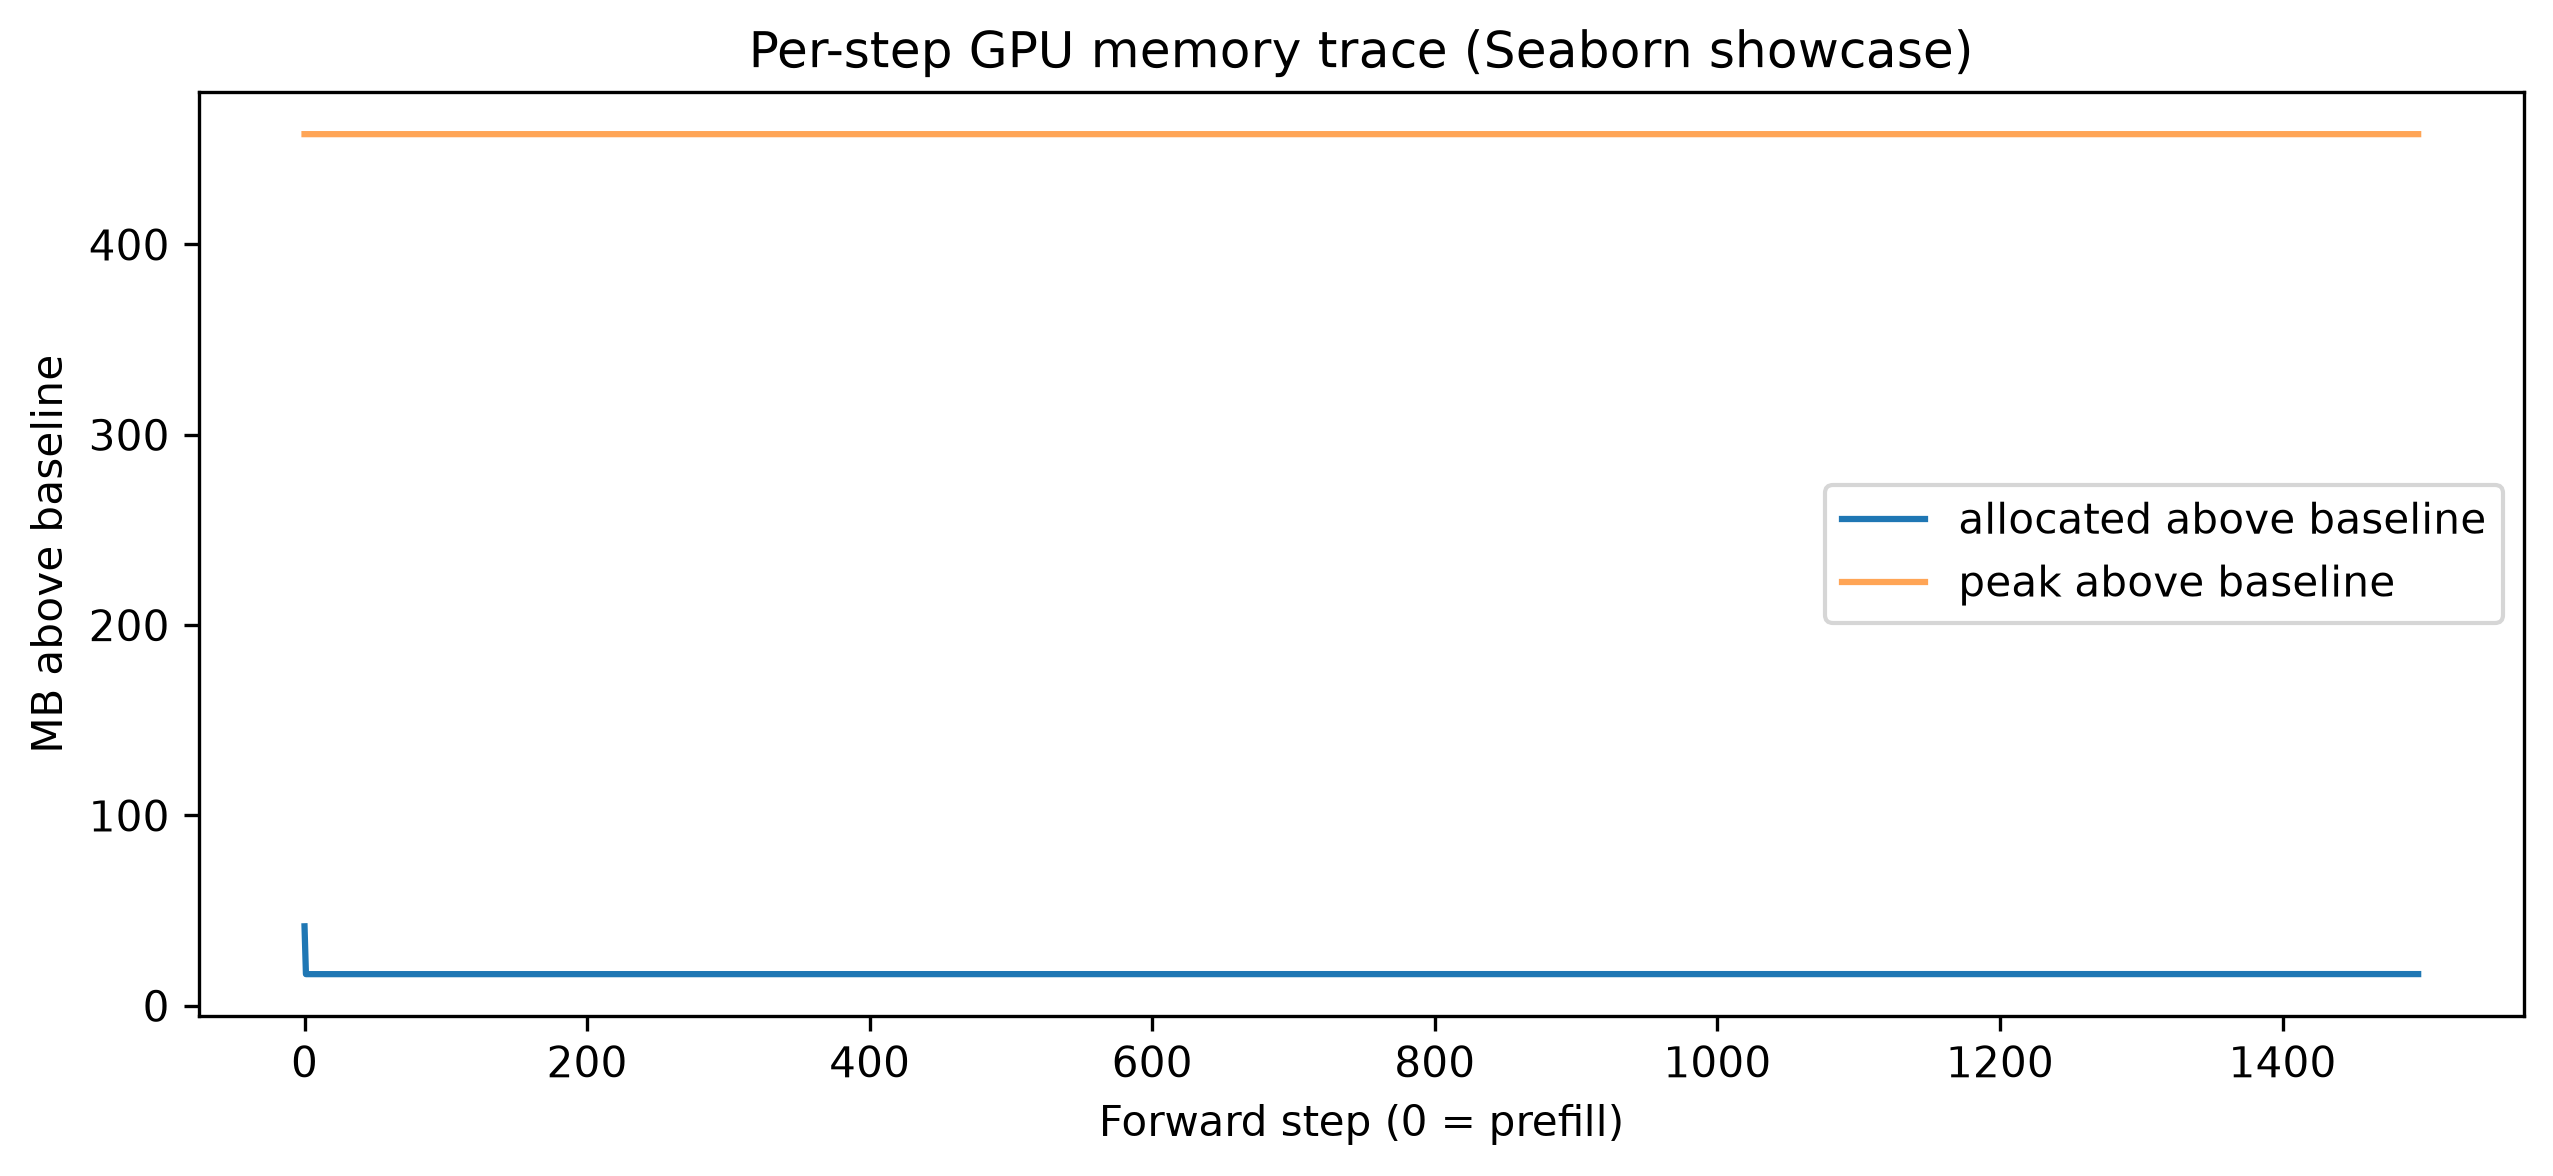

Outputs: memory trace showcase saved


In [12]:
class MemoryTraceShowcase:
    """Save and display the per-step memory trace.

    Parameters
    ----------
    showcase : Showcase
        Required. Shared save/log/display helper.
    """

    def __init__(self, showcase: Showcase):
        """Initialize with the showcase helper.

        Parameters
        ----------
        showcase : Showcase
            Required. Shared save/log/display helper.
        """
        self.showcase = showcase

    def run(self, trace: List[Dict[str, float]], baseline_mb: float) -> None:
        """Save trace sample JSON and a Seaborn line plot.

        Parameters
        ----------
        trace : List[Dict[str, float]]
            Required. Memory trace from the profiler.
        baseline_mb : float
            Required. Allocated memory before generation started.
        """
        allocated = np.array([r["allocated_mb"] for r in trace])
        peak = np.array([r["peak_mb"] for r in trace])
        self.showcase.log_summary("allocated_mb", allocated)
        sample = {
            "num_steps": len(trace),
            "allocated_mb_shape": list(allocated.shape),
            "first_steps": trace[:3],
            "last_steps": trace[-3:],
        }
        self.showcase.save_json(sample, "03_memory_trace_sample.json")

        steps = [r["step"] for r in trace]
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.lineplot(
            x=steps,
            y=allocated - baseline_mb,
            label="allocated above baseline",
            ax=ax,
        )
        sns.lineplot(
            x=steps,
            y=peak - baseline_mb,
            label="peak above baseline",
            alpha=0.7,
            ax=ax,
        )
        ax.set_xlabel("Forward step (0 = prefill)")
        ax.set_ylabel("MB above baseline")
        ax.set_title("Per-step GPU memory trace (Seaborn showcase)")
        self.showcase.save_figure(fig, "03_memory_trace_seaborn.png")


memory_trace_showcase = MemoryTraceShowcase(showcase)
memory_trace_showcase.run(MEMORY_TRACE, profiler._baseline_mb)
logger.info("Outputs: memory trace showcase saved")




## Save Trace and Decode Output
Persist the raw measurements and the model output so the notebook can be
inspected later without re-running generation.




In [13]:
class ResultWriter:
    """Save memory trace, generated text, and summary statistics.

    Parameters
    ----------
    config : Config
        Required. Global configuration.
    tokenizer : AutoTokenizer
        Required. Loaded tokenizer.
    trace : List[Dict[str, float]]
        Required. Memory trace from the profiler.
    output_ids : torch.Tensor
        Required. Generated token ids.
    token_budget : Dict[str, float]
        Required. Token budget computed earlier.
    """

    def __init__(
        self,
        config: Config,
        tokenizer: AutoTokenizer,
        trace: List[Dict[str, float]],
        output_ids: torch.Tensor,
        token_budget: Dict[str, float],
    ):
        """Initialize writer.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        tokenizer : AutoTokenizer
            Required. Loaded tokenizer.
        trace : List[Dict[str, float]]
            Required. Memory trace.
        output_ids : torch.Tensor
            Required. Generated token ids.
        token_budget : Dict[str, float]
            Required. Token budget.
        """
        self.config = config
        self.tokenizer = tokenizer
        self.trace = trace
        self.output_ids = output_ids
        self.token_budget = token_budget
        self.results_dir = config.out_dir / "results"
        self.results_dir.mkdir(parents=True, exist_ok=True)

    def save(self) -> Dict[str, Path]:
        """Write JSON trace, text output, and numeric summary.

        Returns
        -------
        Dict[str, Path]
            Paths to the written artifacts.
        """
        trace_path = self.results_dir / "decoder_memory_trace.json"
        trace_path.write_text(json.dumps(self.trace, indent=2), encoding="utf-8")

        input_length = int(self.trace[0]["seq_len"]) if self.trace else 0
        generated_ids = self.output_ids[0, input_length:]
        text = self.tokenizer.decode(generated_ids, skip_special_tokens=False)
        text_path = self.results_dir / "generated_text.txt"
        text_path.write_text(text, encoding="utf-8")

        summary = {
            "model_name": self.config.model_name,
            "max_pages": self.config.max_pages,
            "image_size": self.config.image_size,
            "visual_tokens": self.token_budget["visual_tokens"],
            "prompt_tokens": self.token_budget["prompt_tokens"],
            "reference_tokens": self.token_budget["reference_tokens"],
            "recent_window": self.token_budget["recent_window"],
            "upper_bound_cache_tokens": self.token_budget["upper_bound_cache_tokens"],
            "upper_bound_cache_mb": self.token_budget["upper_bound_cache_mb"],
            "input_length": input_length,
            "generated_length": int(generated_ids.shape[0]),
            "trace_steps": len(self.trace),
        }
        summary_path = self.results_dir / "run_summary.json"
        summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

        artifacts = {
            "trace": trace_path,
            "text": text_path,
            "summary": summary_path,
        }
        logger.info("[ResultWriter] Wrote %s", artifacts)
        return artifacts


result_writer = ResultWriter(CONFIG, tokenizer, MEMORY_TRACE, OUTPUT_IDS, TOKEN_BUDGET)
RESULT_ARTIFACTS = result_writer.save()
logger.info("Outputs: RESULT_ARTIFACTS=%s", RESULT_ARTIFACTS)
for p in RESULT_ARTIFACTS.values():
    assert p.exists(), f"Missing artifact: {p}"




[ResultWriter] Wrote {'trace': PosixPath('outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/results/decoder_memory_trace.json'), 'text': PosixPath('outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/results/generated_text.txt'), 'summary': PosixPath('outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/results/run_summary.json')}
Outputs: RESULT_ARTIFACTS={'trace': PosixPath('outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/results/decoder_memory_trace.json'), 'text': PosixPath('outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/results/generated_text.txt'), 'summary': PosixPath('outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/results/run_summary.json')}


## Showcase: Generated Text Snippet
Save a snippet of the raw generated text (with special tokens) and display it.




In [14]:
class GeneratedTextShowcase:
    """Save and display a snippet of the generated text.

    Parameters
    ----------
    showcase : Showcase
        Required. Shared save/log/display helper.
    """

    def __init__(self, showcase: Showcase):
        """Initialize with the showcase helper.

        Parameters
        ----------
        showcase : Showcase
            Required. Shared save/log/display helper.
        """
        self.showcase = showcase

    def run(self, text_path: Path, snippet_chars: int = 1000) -> str:
        """Save the first characters of the generated text as a snippet.

        Parameters
        ----------
        text_path : Path
            Required. Path to the full generated text artifact.
        snippet_chars : int
            Optional. Number of characters to keep. Defaults to 1000.

        Returns
        -------
        str
            The saved snippet.
        """
        full_text = text_path.read_text(encoding="utf-8")
        snippet = full_text[:snippet_chars]
        self.showcase.save_text(
            snippet, "04_generated_text_snippet.txt", preview_chars=snippet_chars
        )
        logger.info(
            "[GeneratedTextShowcase] full=%d chars snippet=%d chars",
            len(full_text),
            len(snippet),
        )
        return snippet


generated_text_showcase = GeneratedTextShowcase(showcase)
generated_snippet = generated_text_showcase.run(RESULT_ARTIFACTS["text"])
logger.info("Outputs: generated_snippet len=%d", len(generated_snippet))
assert len(generated_snippet) > 0




[Showcase] 04_generated_text_snippet.txt: str len=1000
[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/04_generated_text_snippet.txt (1000 bytes)


```text
<PAGE><|det|>table [0, 0, 999, 999]<|/det|><table><tr><td></td><td></td><td></td></tr><tr><td></td><td>1</td><td>2</td></tr><tr><td>1</td><td>3</td><td>4</td></tr><tr><td>2</td><td>5</td><td>6</td></tr><tr><td>3</td><td>6</td><td>7</td></tr><tr><td>4</td><td>7</td><td>8</td></tr><tr><td>5</td><td>8</td><td>9</td></tr><tr><td>6</td><td>9</td><td>10</td></tr><tr><td>7</td><td>10</td><td>11</td></tr><tr><td>8</td><td>11</td><td>12</td></tr><tr><td>9</td><td>12</td><td>13</td></tr><tr><td>10</td><td>13</td><td>14</td></tr><tr><td>11</td><td>14</td><td>15</td></tr><tr><td>12</td><td>15</td><td>16</td></tr><tr><td>13</td><td>16</td><td>17</td></tr><tr><td>14</td><td>17</td><td>18</td></tr><tr><td>15</td><td>18</td><td>19</td></tr><tr><td>16</td><td>19</td><td>20</td></tr><tr><td>17</td><td>20</td><td>21</td></tr></td><td>21</td><td>22</td></tr></td><td>22</td><td>22</td></td></tr></td><td>23</td><td>23</td></td><td>24</td><td>24</td></tr><td>24</td><td>25</td><td>26</td><td>26</td></td><td>2
```

[GeneratedTextShowcase] full=4218 chars snippet=1000 chars
Outputs: generated_snippet len=1000


## Plot Measured Memory and Theoretical Cache
Draw two figures:
  1. The measured allocated and peak allocated GPU memory per forward step.
     The prefill step is high; decode steps should flatten after the recent
     window is filled.
  2. The theoretical KV-cache token count for vanilla full attention vs R-SWA.




In [15]:
class MemoryPlotter:
    """Plot the measured memory trace and the theoretical cache curves.

    Parameters
    ----------
    config : Config
        Required. Global configuration.
    trace : List[Dict[str, float]]
        Required. Memory trace from the profiler.
    token_budget : Dict[str, float]
        Required. Token budget.
    """

    def __init__(
        self,
        config: Config,
        trace: List[Dict[str, float]],
        token_budget: Dict[str, float],
    ):
        """Initialize plotter.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        trace : List[Dict[str, float]]
            Required. Memory trace.
        token_budget : Dict[str, float]
            Required. Token budget.
        """
        self.config = config
        self.trace = trace
        self.token_budget = token_budget
        self.plots_dir = config.out_dir / "plots"
        self.plots_dir.mkdir(parents=True, exist_ok=True)

    def _save(self, name: str) -> Path:
        """Return a fresh plot path.

        Parameters
        ----------
        name : str
            Required. Plot file name.

        Returns
        -------
        Path
            Plot path.
        """
        return self.plots_dir / name

    def plot_memory_trace(self, baseline_mb: float) -> Path:
        """Plot measured allocated and peak allocated memory per forward step.

        Parameters
        ----------
        baseline_mb : float
            Required. Allocated memory before generation started.

        Returns
        -------
        Path
            Path to the saved PNG.
        """
        prefill = self.trace[0]
        decode = self.trace[1:]
        decode_steps = [r["step"] for r in decode]
        decode_allocated = [r["allocated_mb"] - baseline_mb for r in decode]
        decode_peak = [r["peak_mb"] - baseline_mb for r in decode]

        fig, ax = plt.subplots(figsize=(10, 5))
        # prefill shown as a single marker, decode shown as a line
        ax.scatter(
            [prefill["step"]],
            [prefill["allocated_mb"] - baseline_mb],
            color="green",
            s=80,
            zorder=5,
            label="Prefill allocated memory",
        )
        ax.scatter(
            [prefill["step"]],
            [prefill["peak_mb"] - baseline_mb],
            color="darkgreen",
            s=80,
            marker="s",
            zorder=5,
            label="Prefill peak allocated memory",
        )
        ax.plot(
            decode_steps,
            decode_allocated,
            label="Decode allocated memory",
            lw=1.2,
        )
        ax.plot(
            decode_steps,
            decode_peak,
            label="Decode peak allocated memory",
            lw=1.2,
            alpha=0.8,
        )
        ax.axvline(
            x=TOKEN_BUDGET["recent_window"],
            color="red",
            linestyle="--",
            label="Ring-buffer warm-up end",
        )
        ax.set_xlabel("Forward step (0 = prefill)")
        ax.set_ylabel("Memory above model-weight baseline (MB)")
        ax.set_title(
            "Unlimited-OCR decoder memory stays flat after the recent window is warm"
        )
        ax.legend()
        ax.grid(True, alpha=0.3)

        path = self._save("decoder_memory_allocated_peak.png")
        plt.tight_layout()
        plt.savefig(path, dpi=200)
        plt.close(fig)
        logger.info("[MemoryPlotter] Saved %s", path)
        return path

    def plot_cache_theory(self, generated_length: int) -> Path:
        """Plot theoretical KV-cache size: full attention vs R-SWA.

        Parameters
        ----------
        generated_length : int
            Required. Number of generated tokens to plot.

        Returns
        -------
        Path
            Path to the saved PNG.
        """
        lm = self.token_budget["reference_tokens"]
        n = self.token_budget["recent_window"]
        ts = np.arange(0, generated_length + 1)
        full_attention = lm + ts
        rswa = lm + np.minimum(ts, n)

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(ts, full_attention, label="Vanilla full attention (L_m + T)", lw=2)
        ax.plot(ts, rswa, label=f"R-SWA (L_m + min(T, {n}))", lw=2)
        ax.axhline(
            lm + n,
            color="red",
            linestyle="--",
            label=f"R-SWA upper bound ({lm + n})",
        )
        ax.set_xlabel("Generated tokens T")
        ax.set_ylabel("KV-cache tokens")
        ax.set_title(
            "Theoretical KV-cache size: full attention grows, R-SWA is constant"
        )
        ax.legend()
        ax.grid(True, alpha=0.3)

        path = self._save("kv_cache_theory.png")
        plt.tight_layout()
        plt.savefig(path, dpi=200)
        plt.close(fig)
        logger.info("[MemoryPlotter] Saved %s", path)
        return path


memory_plotter = MemoryPlotter(CONFIG, MEMORY_TRACE, TOKEN_BUDGET)
memory_trace_path = memory_plotter.plot_memory_trace(profiler._baseline_mb)
cache_theory_path = memory_plotter.plot_cache_theory(generated_count)
logger.info(
    "Outputs: memory_trace_path=%s cache_theory_path=%s",
    memory_trace_path,
    cache_theory_path,
)
assert memory_trace_path.exists()
assert cache_theory_path.exists()




[MemoryPlotter] Saved outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/plots/decoder_memory_allocated_peak.png
[MemoryPlotter] Saved outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/plots/kv_cache_theory.png
Outputs: memory_trace_path=outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/plots/decoder_memory_allocated_peak.png cache_theory_path=outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/plots/kv_cache_theory.png


## Validate Constant Memory
Confirm that, after the recent window is warm, the allocated memory does not
drift upward.  A drifting value would indicate the KV cache is still growing.




In [16]:
class MemoryValidator:
    """Check that decode memory stays flat after the ring buffer is warm.

    Parameters
    ----------
    trace : List[Dict[str, float]]
        Required. Memory trace.
    recent_window : int
        Required. Recent-token window size.
    """

    def __init__(self, trace: List[Dict[str, float]], recent_window: int):
        """Initialize validator.

        Parameters
        ----------
        trace : List[Dict[str, float]]
            Required. Memory trace.
        recent_window : int
            Required. Recent window.
        """
        self.trace = trace
        self.recent_window = recent_window

    def validate(self) -> Dict[str, float]:
        """Compute mean and standard deviation of decode memory after warm-up.

        Returns
        -------
        Dict[str, float]
            Statistics and the validation pass flag.
        """
        steady_steps = [r for r in self.trace if r["step"] > self.recent_window]
        if not steady_steps:
            raise ValueError("Not enough decode steps to validate steady-state memory")
        allocated = [r["allocated_mb"] for r in steady_steps]
        mean_mb = float(np.mean(allocated))
        std_mb = float(np.std(allocated))
        drift = float(allocated[-1] - allocated[0])
        passed = abs(drift) < 50.0 and std_mb < 25.0

        stats = {
            "steady_steps": len(steady_steps),
            "mean_allocated_mb": mean_mb,
            "std_allocated_mb": std_mb,
            "drift_mb": drift,
            "passed": passed,
        }
        logger.info("[MemoryValidator] Steady-state stats:")
        for key, value in stats.items():
            logger.info("  %s = %s", key, value)
        return stats


validator = MemoryValidator(MEMORY_TRACE, int(TOKEN_BUDGET["recent_window"]))
VALIDATION_STATS = validator.validate()
logger.info("Outputs: VALIDATION_STATS=%s", VALIDATION_STATS)
assert VALIDATION_STATS[
    "passed"
], f"Memory drifted {VALIDATION_STATS['drift_mb']:.1f} MB; expected constant KV cache"




[MemoryValidator] Steady-state stats:
  steady_steps = 1368
  mean_allocated_mb = 6492.358093261719
  std_allocated_mb = 0.009043930000886794
  drift_mb = 0.03076171875
  passed = True
Outputs: VALIDATION_STATS={'steady_steps': 1368, 'mean_allocated_mb': 6492.358093261719, 'std_allocated_mb': 0.009043930000886794, 'drift_mb': 0.03076171875, 'passed': True}


## Validate Intermediate Artifacts
Verify that every showcase artifact was saved and is non-empty.




In [17]:
for fname in (
    "00_input_page.png",
    "01_token_budget.json",
    "02_receptive_field_mask.npy",
    "02_receptive_field_mask_heatmap.png",
    "03_memory_trace_sample.json",
    "03_memory_trace_seaborn.png",
    "04_generated_text_snippet.txt",
):
    path = showcase.dir / fname
    assert path.exists() and path.stat().st_size > 0, f"Missing intermediate: {path}"
    logger.info("[Validation] Found intermediate %s", path)
logger.info("[Validation] All intermediate artifacts exist and are non-empty")




[Validation] Found intermediate outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/00_input_page.png
[Validation] Found intermediate outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/01_token_budget.json
[Validation] Found intermediate outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/02_receptive_field_mask.npy
[Validation] Found intermediate outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/02_receptive_field_mask_heatmap.png
[Validation] Found intermediate outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/03_memory_trace_sample.json
[Validation] Found intermediate outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/03_memory_trace_seaborn.png
[Validation] Found intermediate outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/intermediate/04_generated_text_snippet.txt
[Validation] All intermediate artifacts exist an

## Final Summary
Print the key take-aways: visual token count, recent window, measured memory
drift, and where the artifacts live.




In [18]:
logger.info("\n=== Unlimited-OCR attention-memory summary ===")
logger.info("Reference (visual + prompt) tokens: %s", TOKEN_BUDGET["reference_tokens"])
logger.info("Recent-output window size: %s", TOKEN_BUDGET["recent_window"])
logger.info("Upper-bound KV-cache tokens: %s", TOKEN_BUDGET["upper_bound_cache_tokens"])
logger.info("Upper-bound KV-cache size: %.2f MB", TOKEN_BUDGET["upper_bound_cache_mb"])
logger.info("Generated tokens: %s", generated_count)
logger.info("Steady-state memory mean: %.2f MB", VALIDATION_STATS["mean_allocated_mb"])
logger.info("Steady-state memory std: %.2f MB", VALIDATION_STATS["std_allocated_mb"])
logger.info("Memory drift after warm-up: %.2f MB", VALIDATION_STATS["drift_mb"])
logger.info("Artifacts:")
for name, path in RESULT_ARTIFACTS.items():
    logger.info("  %s: %s", name, path)
logger.info("Plots:")
logger.info("  decoder_memory_allocated_peak: %s", memory_trace_path)
logger.info("  kv_cache_theory: %s", cache_theory_path)
logger.info("  attention_receptive_field: %s", receptive_field_path)
logger.info("\nKey paper insight:")
logger.info(
    "R-SWA keeps every visual/reference token (L_m) and only the latest %s "
    "output tokens (n).  Therefore the KV cache is bounded by L_m + n, "
    "not L_m + T, which is why the measured GPU memory stays flat.",
    TOKEN_BUDGET["recent_window"],
)





=== Unlimited-OCR attention-memory summary ===
Reference (visual + prompt) tokens: 551
Recent-output window size: 128
Upper-bound KV-cache tokens: 679
Upper-bound KV-cache size: 39.79 MB
Generated tokens: 1497
Steady-state memory mean: 6492.36 MB
Steady-state memory std: 0.01 MB
Memory drift after warm-up: 0.03 MB
Artifacts:
  trace: outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/results/decoder_memory_trace.json
  text: outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/results/generated_text.txt
  summary: outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/results/run_summary.json
Plots:
  decoder_memory_allocated_peak: outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/plots/decoder_memory_allocated_peak.png
  kv_cache_theory: outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/plots/kv_cache_theory.png
  attention_receptive_field: outputs/2026-07-26/000-unlimited-ocr-demo/002-attentionconstant/plots/attention_rece

## Display Plots
Render the saved R-SWA plots inline when running in a notebook.



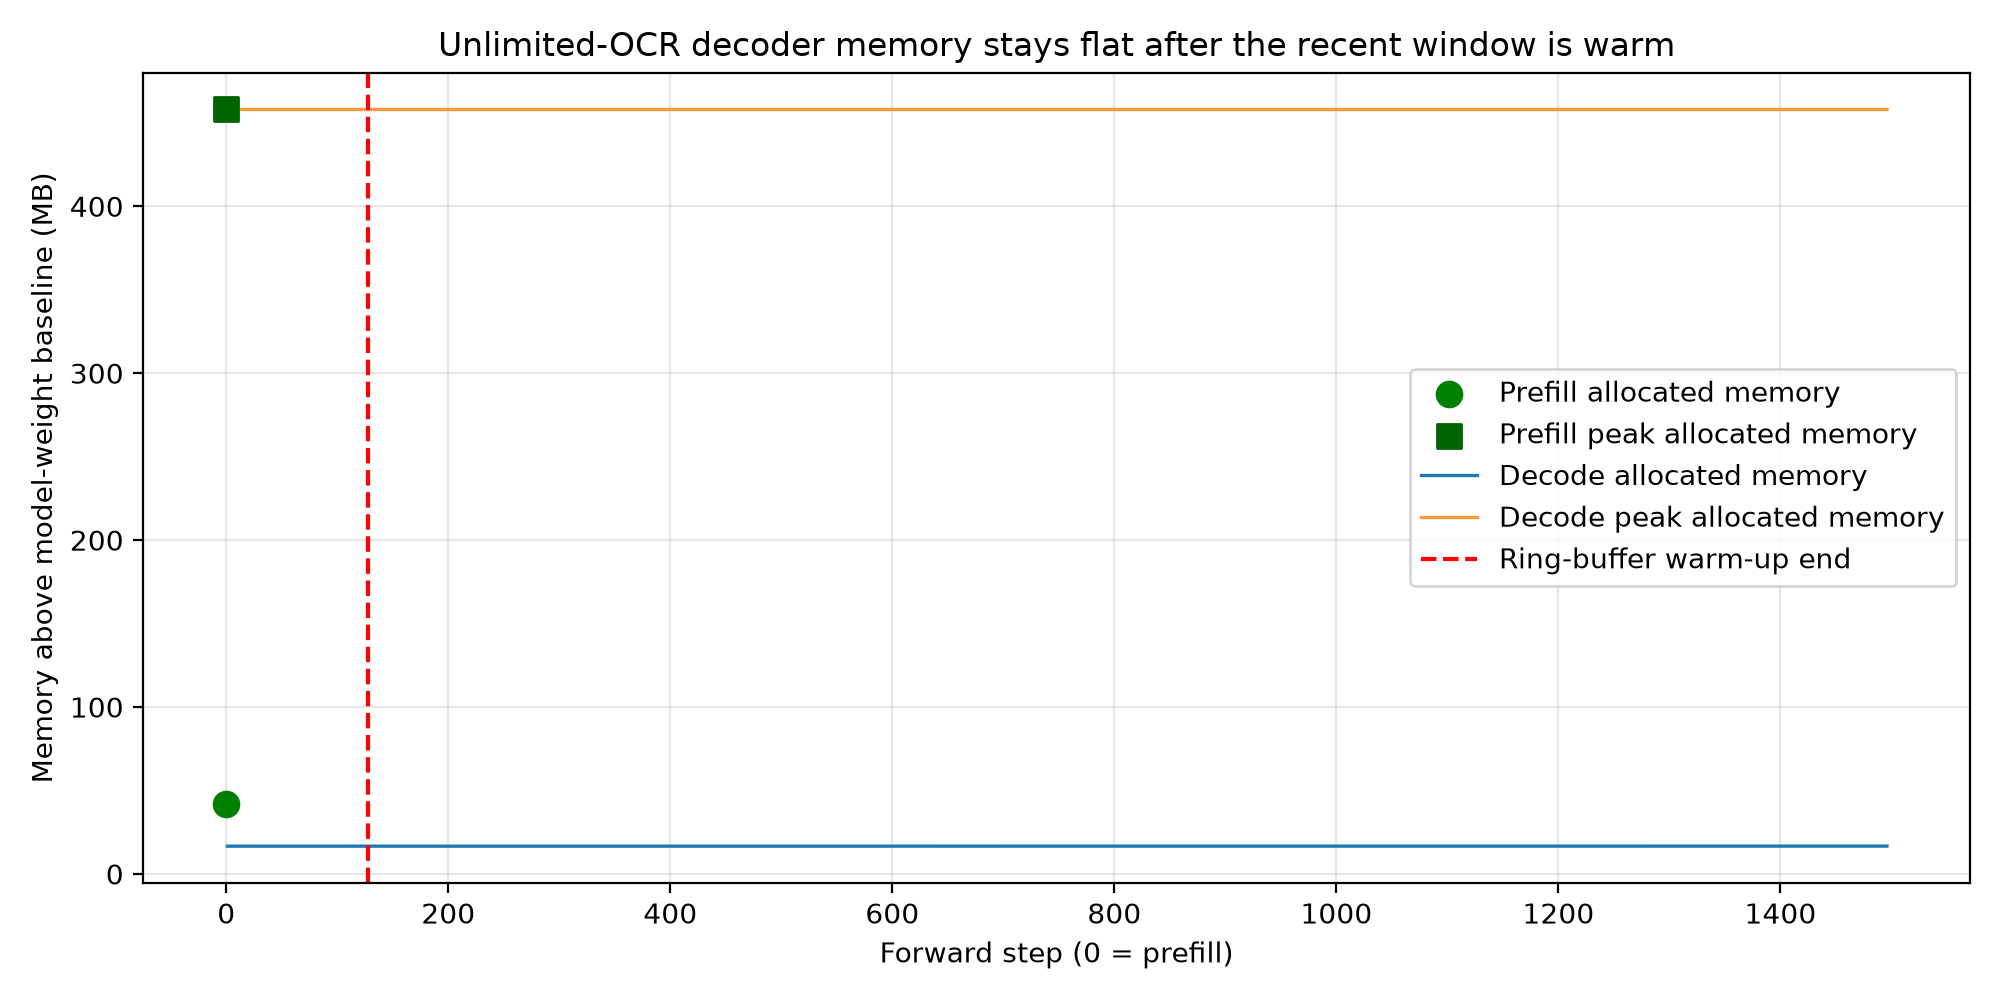

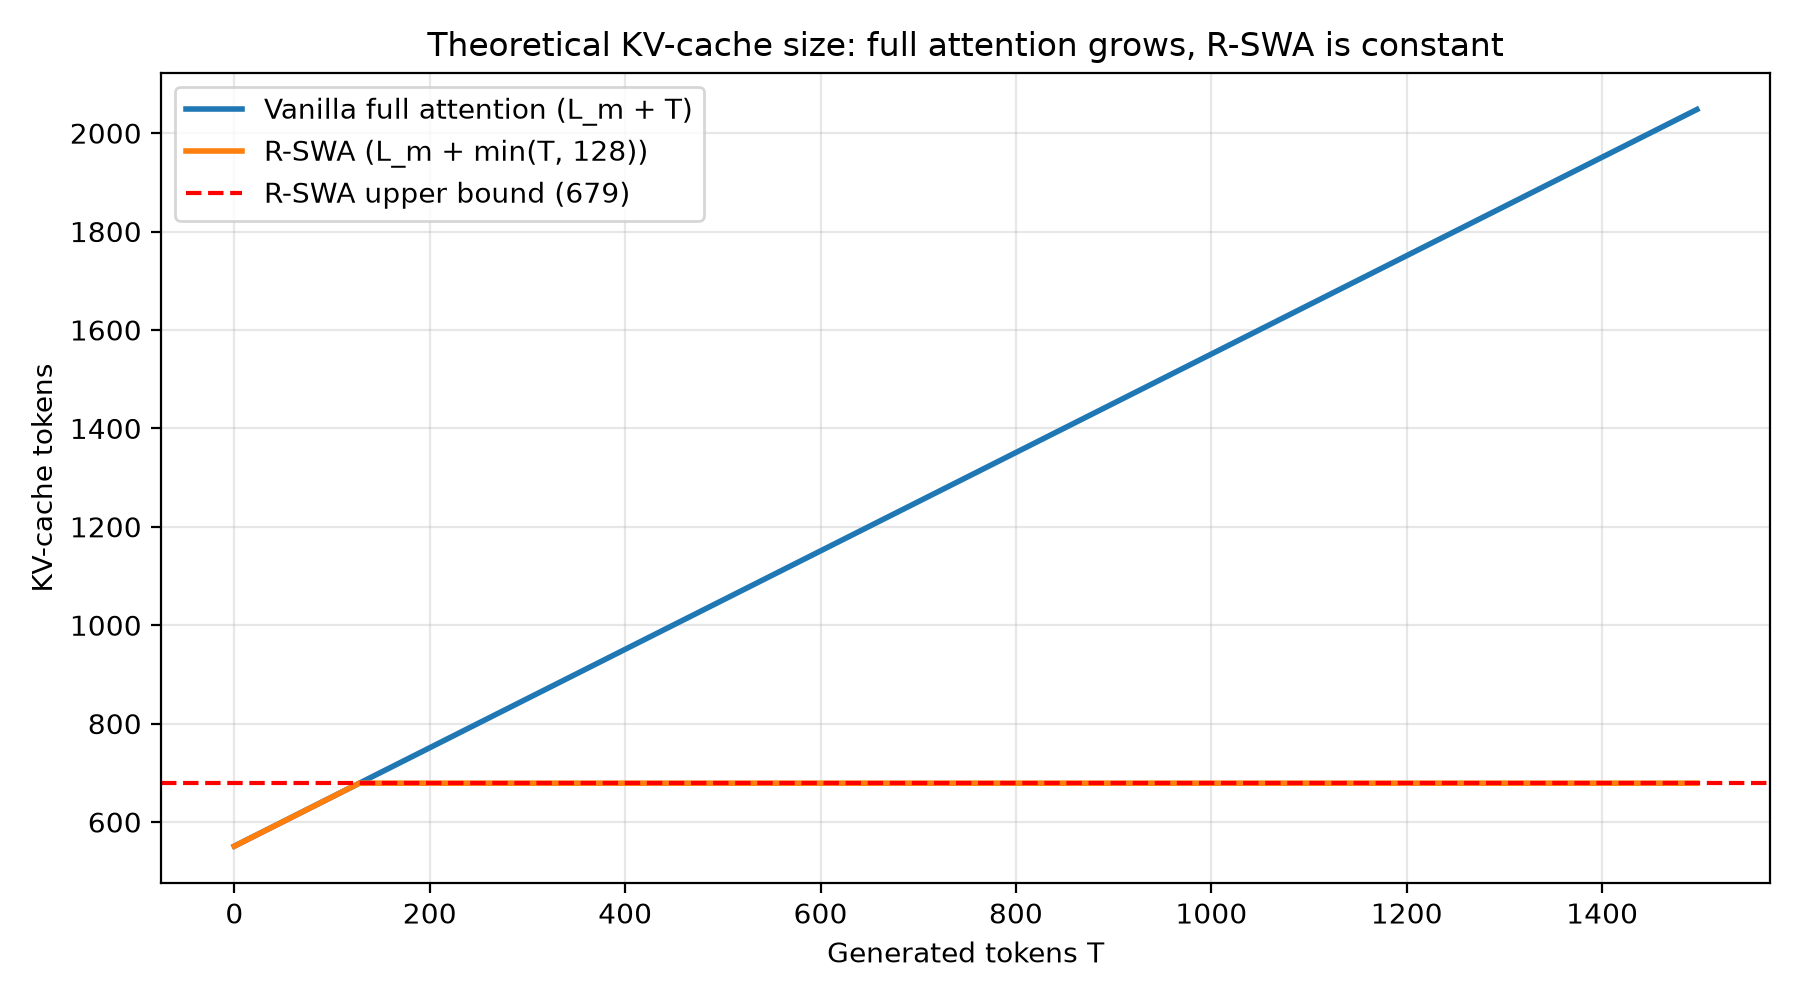

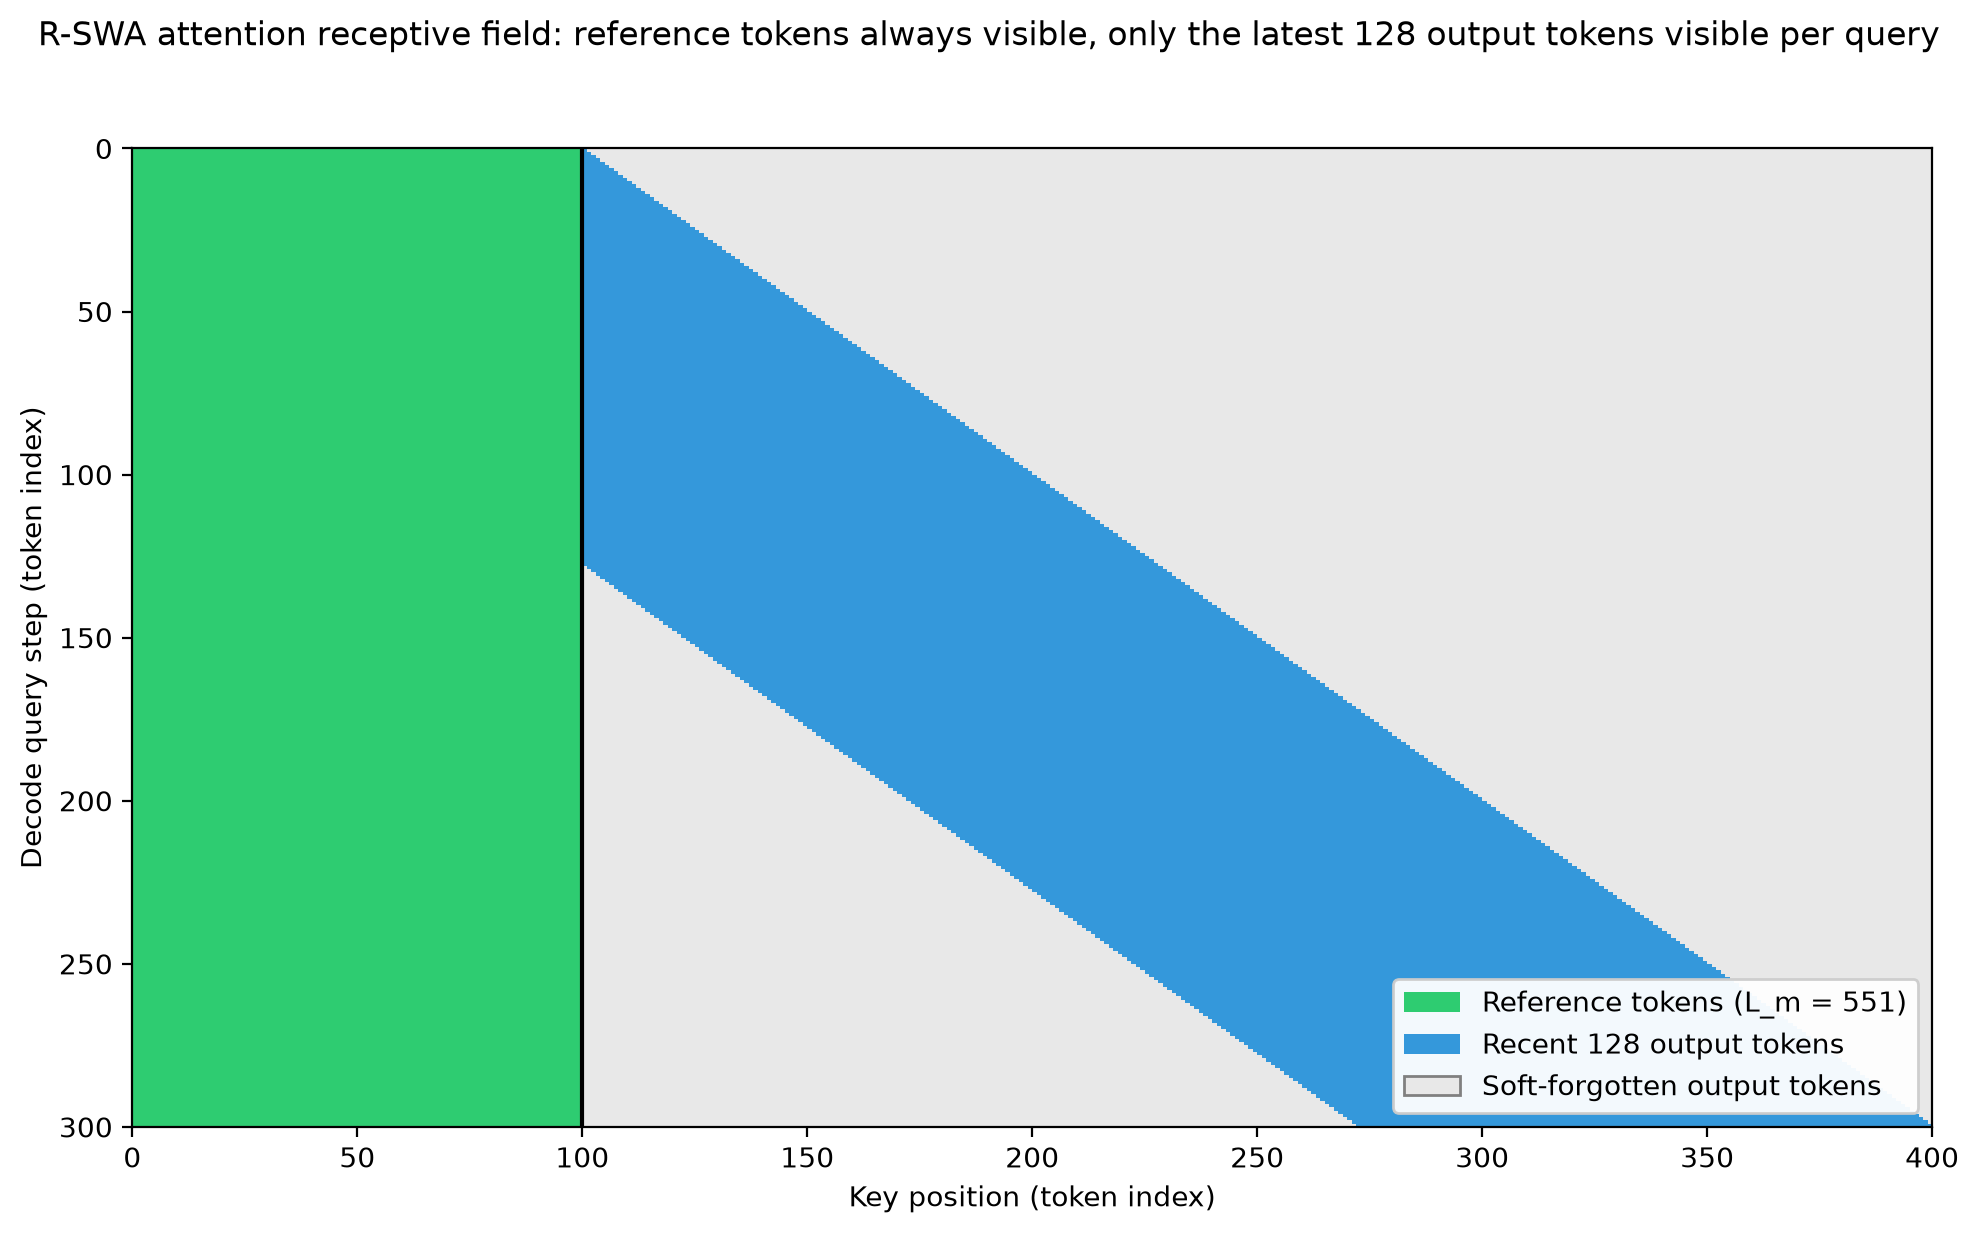

In [19]:
try:
    for plot_path in (
        memory_trace_path,
        cache_theory_path,
        receptive_field_path,
    ):
        if plot_path.exists():
            display(IPImage(filename=str(plot_path)))
except Exception as exc:  # noqa: BLE001
    logger.info("Display skipped (not running in a notebook frontend): %s", exc)
